In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

# Libraries for Data encoding and models
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

In [2]:
# Reading the data and making copies
data = pd.read_csv("train.csv")
df = data.copy()

store_data = pd.read_csv("store.csv")
store_df = store_data.copy()

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

### Exploring and Cleaning train data

In [ ]:
# Showing the first 5 rows of train data
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
# Showing the last 5 rows of train data
df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1
1017208,1115,2,2013-01-01,0,0,0,0,a,1


In [ ]:
# Checking the shape of train_df
df.shape

(1017209, 9)

In [ ]:
# train data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [ ]:
# Converting 'Date' from object to datetime dtype
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# Statistical information about train data
df.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01


In [9]:
# Checking missing values
df.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [10]:
# Cheching Duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
# Showing the number of values in 'Open' Column
df['Open'].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [12]:
# Showing the number of values in 'StateHoliday'
df['StateHoliday'].value_counts()

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [13]:
# Getting the Unique values in the following columns
print(f"Unique values of DayOfWeek: {df['DayOfWeek'].unique()}")
print(f"Unique values of Open: {df['Open'].unique()}")
print(f"Unique values of Promo: {df['Promo'].unique()}")
print(f"Unique values of StateHoliday: {df['StateHoliday'].unique()}")
print(f"Unique values of SchoolHoliday: {df['SchoolHoliday'].unique()}")

Unique values of DayOfWeek: [5 4 3 2 1 7 6]
Unique values of Open: [1 0]
Unique values of Promo: [1 0]
Unique values of StateHoliday: ['0' 'a' 'b' 'c' 0]
Unique values of SchoolHoliday: [1 0]


In [14]:
# Fixing values (Convert int values to string)
df['StateHoliday'] = df['StateHoliday'].replace(0, '0')

In [15]:
# Showing the number of values in 'SchoolHoliday'
df['SchoolHoliday'].value_counts()

SchoolHoliday
0    835488
1    181721
Name: count, dtype: int64

In [16]:
# Getting data with zero sales
zeros_sales = df[df['Sales'] == 0]

In [17]:
# Getting the number of values in 'Open' column that have zero sales
zeros_sales['Open'].value_counts()

Open
0    172817
1        54
Name: count, dtype: int64

In [18]:
# Dropping rows when it's closed
drop_rows = df[df['Open'] == 0]
df.drop(drop_rows.index, axis=0, inplace=True)

### Exploring and Handling Store Data 

In [19]:
# Getting the first 5 rows in store data
store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [20]:
# Getting information about store data
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [21]:
# Getting the shape
store_df.shape

(1115, 10)

In [22]:
# Checking missing values
store_df.isna().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [23]:
# Getting the percentage of missing values
(store_df.isna().sum() / store_df.shape[0]) *100

Store                         0.000000
StoreType                     0.000000
Assortment                    0.000000
CompetitionDistance           0.269058
CompetitionOpenSinceMonth    31.748879
CompetitionOpenSinceYear     31.748879
Promo2                        0.000000
Promo2SinceWeek              48.789238
Promo2SinceYear              48.789238
PromoInterval                48.789238
dtype: float64

In [24]:
# Checking Duplicates
store_df.duplicated().sum()

np.int64(0)

In [25]:
# Getting the unique values in thw following columns
print(f"Unique values of StoreType: {store_df['StoreType'].unique()}")
print(f"Unique values of Assortment: {store_df['Assortment'].unique()}")
print(f"Unique values of Promo2: {store_df['Promo2'].unique()}")
print(f"Unique values of PromoInterval: {store_df['PromoInterval'].unique()}")

Unique values of StoreType: ['c' 'a' 'd' 'b']
Unique values of Assortment: ['a' 'c' 'b']
Unique values of Promo2: [0 1]
Unique values of PromoInterval: [nan 'Jan,Apr,Jul,Oct' 'Feb,May,Aug,Nov' 'Mar,Jun,Sept,Dec']


In [26]:
# Getting the number of values in the following columns
print(f"Number of Values in StoreType:\n {store_df['StoreType'].value_counts()}")
print("="*80)
print(f"Number of Values in Assortment:\n {store_df['Assortment'].value_counts()}")
print("="*80)
print(f"Number of Values in Promo2:\n {store_df['Promo2'].value_counts()}")
print("="*80)
print(f"Number of Values in PromoInterval:\n {store_df['PromoInterval'].value_counts()}")
print("="*80)


Number of Values in StoreType:
 StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64
Number of Values in Assortment:
 Assortment
a    593
c    513
b      9
Name: count, dtype: int64
Number of Values in Promo2:
 Promo2
1    571
0    544
Name: count, dtype: int64
Number of Values in PromoInterval:
 PromoInterval
Jan,Apr,Jul,Oct     335
Feb,May,Aug,Nov     130
Mar,Jun,Sept,Dec    106
Name: count, dtype: int64


### Handling Missing Values

In [27]:
# Getting the data where 'CompetitionDistance' has missing values
store_df[store_df['CompetitionDistance'].isna()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [28]:
# Getting the data where 'CompetitionOpenSinceMonth' has missing values
store_df[store_df['CompetitionOpenSinceMonth'].isna()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [29]:
# Getting the data where 'Promo2SinceWeek' has missing values
store_df[store_df['Promo2SinceWeek'].isna()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1107,1108,a,a,540.0,4.0,2004.0,0,NaN,NaN,NaN
1109,1110,c,c,900.0,9.0,2010.0,0,NaN,NaN,NaN
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN


In [30]:
# Getting the data where 'PromoInterval' has missing values
store_df[store_df['PromoInterval'].isna()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1107,1108,a,a,540.0,4.0,2004.0,0,NaN,NaN,NaN
1109,1110,c,c,900.0,9.0,2010.0,0,NaN,NaN,NaN
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN


In [31]:
# Filling missing values in ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear'] with zero
store_df[['CompetitionOpenSinceMonth', 
          'CompetitionOpenSinceYear', 
          'Promo2SinceWeek', 
          'Promo2SinceYear']] = store_df[['CompetitionOpenSinceMonth', 
                                        'CompetitionOpenSinceYear', 
                                        'Promo2SinceWeek', 
                                        'Promo2SinceYear']].fillna(0)

# Filling missing values in CompetitionDistance with mean
store_df['CompetitionDistance'] = store_df['CompetitionDistance'].fillna(store_df['CompetitionDistance'].mean())

# Filling missing values in PromoInterval with 'No Promo'
store_df['PromoInterval'] = store_df['PromoInterval'].fillna('No Promo')

### Merging train and store data

In [32]:
# Merging traind and store data in one dataframe
train_store = pd.merge(df, store_df, how="inner", on='Store')

In [33]:
# Getting the first 5 rows
train_store.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,No Promo
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,No Promo
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,No Promo


In [34]:
# Getting the shape after merging
train_store.shape

(844392, 18)

In [35]:
# Getting Statistical information
train_store.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,844392.000000,844392.000000,844392,844392.000000,844392.000000,844392.0,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000
mean,558.422920,3.520361,2014-04-11 01:02:42.487565056,6955.514291,762.728395,1.0,0.446352,0.193580,5457.842215,4.926491,1369.688401,0.498684,11.596118,1003.230065
min,1.000000,1.000000,2013-01-01 00:00:00,0.000000,0.000000,1.0,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,280.000000,2.000000,2013-08-16 00:00:00,4859.000000,519.000000,1.0,0.000000,0.000000,710.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,558.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,1.0,0.000000,0.000000,2330.000000,4.000000,2006.000000,0.000000,0.000000,0.000000
75%,837.000000,5.000000,2014-12-10 00:00:00,8360.000000,893.000000,1.0,1.000000,0.000000,6880.000000,9.000000,2011.000000,1.000000,22.000000,2012.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.0,1.000000,1.000000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000
std,321.731914,1.723689,NaN,3104.214680,401.227674,0.0,0.497114,0.395103,7799.322503,4.283663,935.558173,0.499999,15.307873,1005.874806


In [36]:
# Getting numerical values only
num_cols = list(set(df.describe().columns) - set(['Date', 'Store', 'CompetitionOpenSinceYear', 'Promo2SinceYear', 'Open']))
num_cols

['DayOfWeek', 'SchoolHoliday', 'Customers', 'Promo', 'Sales']

array([[<Axes: title={'center': 'DayOfWeek'}>,
        <Axes: title={'center': 'SchoolHoliday'}>],
       [<Axes: title={'center': 'Customers'}>,
        <Axes: title={'center': 'Promo'}>],
       [<Axes: title={'center': 'Sales'}>, <Axes: >]], dtype=object)

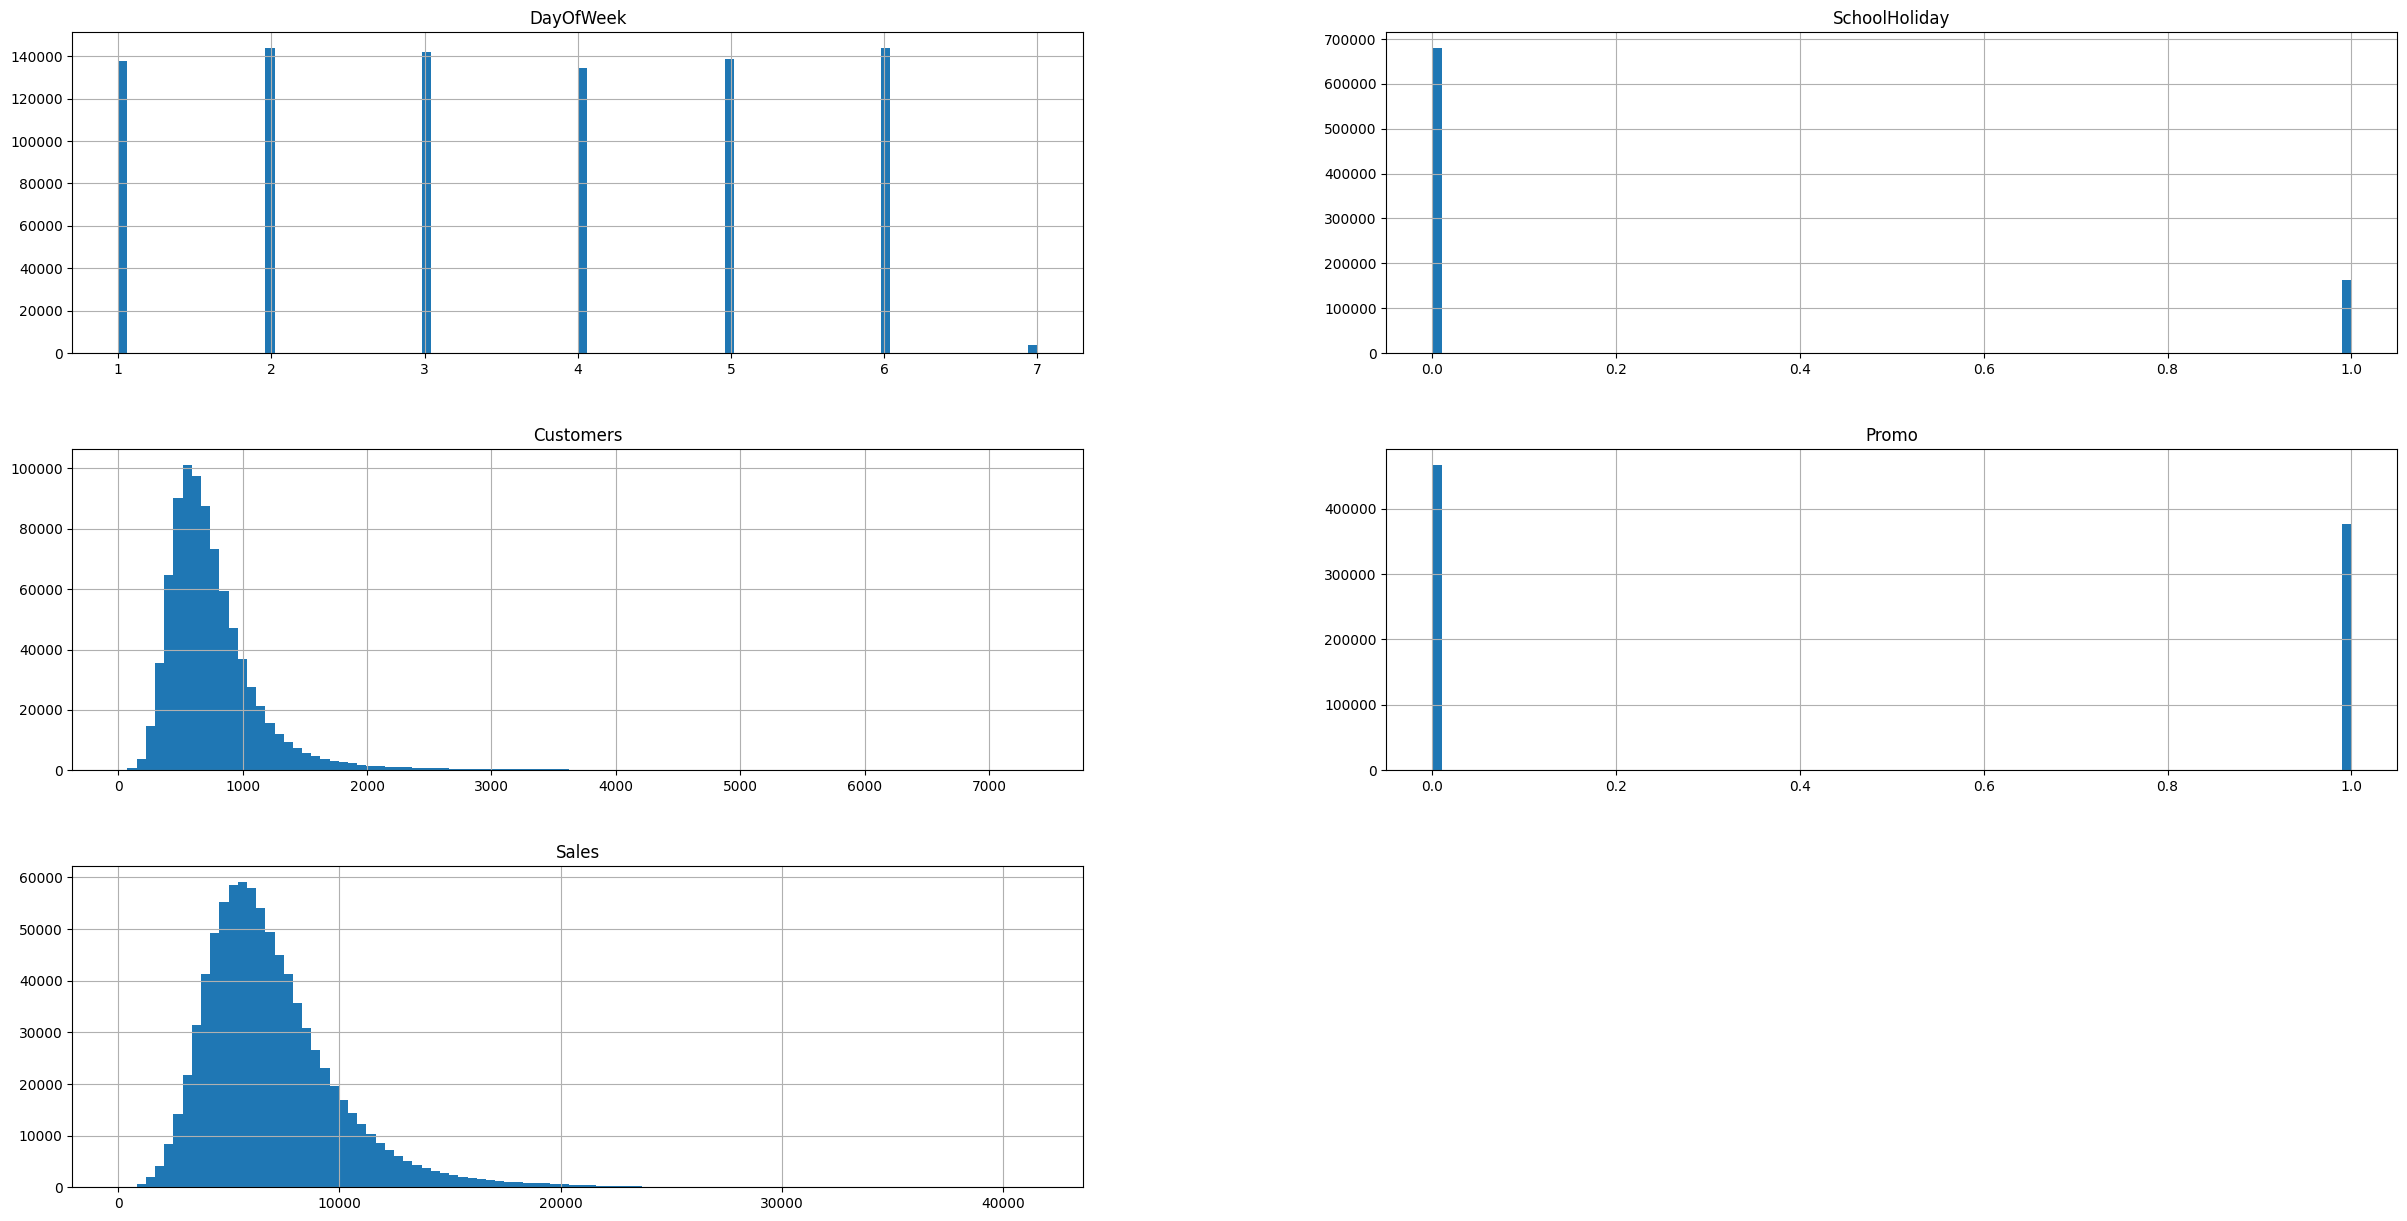

In [37]:
# Visualize histplot of numerical data
df[num_cols].hist(bins=100, figsize=(30, 15))

In [38]:
num_cols = list(set(['Customers', 'CompetitionDistance', 'Sales']))

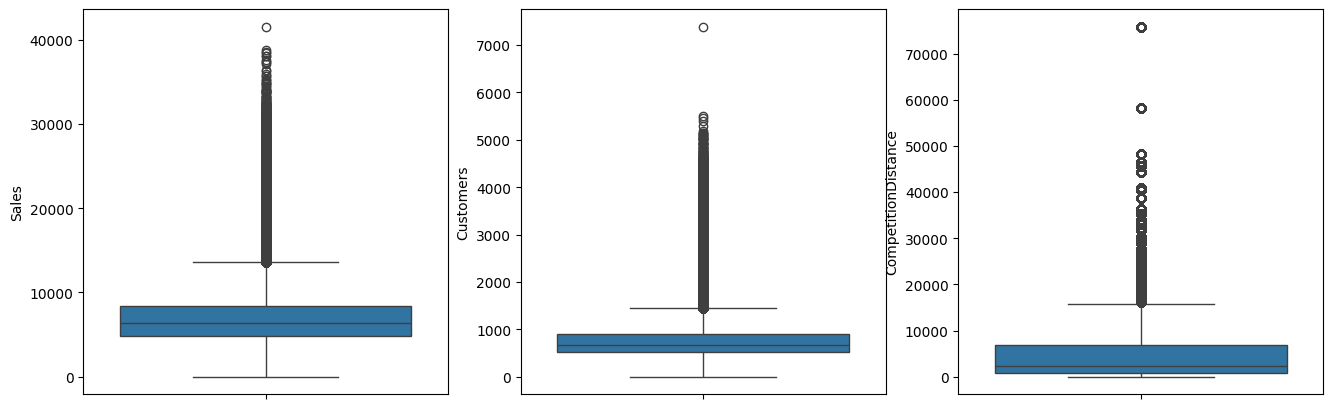

In [39]:
# Visulize Boxplot 
plt.figure(figsize=(16, 5))

for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(train_store[col])


plt.show()

<Axes: xlabel='Sales', ylabel='Count'>

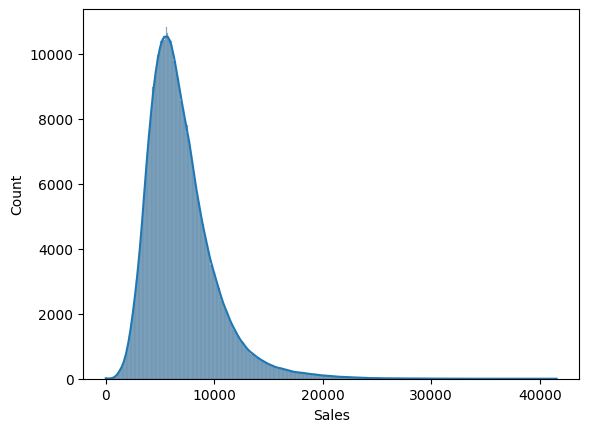

In [40]:
sns.histplot(data=train_store, x='Sales', kde=True)

### Feature Engineering

In [41]:
# Spliting Date into year, month , day, weekofyear
train_store['Year'] = train_store['Date'].dt.year
train_store['Month'] = train_store['Date'].dt.month
train_store['Day'] = train_store['Date'].dt.day
train_store['WeekofYear'] = train_store['Date'].dt.isocalendar().week

# Adding Sales per customer feature and filling NAN values with 0
train_store['SalesPerCustomer'] = train_store['Sales'] / train_store['Customers']
train_store['SalesPerCustomer'] = train_store['SalesPerCustomer'].fillna(0)

# Create new column for Competitors Open (in months)
train_store['CompetitionOpen_month'] = 12 * (train_store['Year'] - train_store['CompetitionOpenSinceYear']) + (train_store['Month'] - train_store['CompetitionOpenSinceMonth'])

# Create new column showing the duration of the promotion in months
train_store['Promo2Open'] = 12 * (train_store['Year'] - train_store['Promo2SinceYear']) + (train_store['WeekofYear'] - train_store['Promo2SinceWeek']) / 4

# Add seasons features
def get_season(month):
    if month in (12, 1, 2):
        return 'Winter'
    elif month in (3, 4, 5):
        return 'Spring'
    elif month in (6, 7, 8):
        return 'Summer'
    else:
        return 'Autumn'
    
# Apply to dataframe
train_store['Seasons'] = train_store['Month'].apply(get_season)

In [42]:
train_store.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekofYear,SalesPerCustomer,CompetitionOpen_month,Promo2Open,Seasons
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,No Promo,2015,7,31,31,9.482883,82.0,24187.75,Summer
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,9.702400,92.0,64.5,Summer
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,10.126675,103.0,52.25,Summer
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,No Promo,2015,7,31,31,9.342457,70.0,24187.75,Summer
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,No Promo,2015,7,31,31,8.626118,3.0,24187.75,Summer


In [43]:
train_store.shape

(844392, 26)

### Exploring Data

In [44]:
train_store.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,Year,Month,Day,WeekofYear,SalesPerCustomer,CompetitionOpen_month,Promo2Open
count,844392.000000,844392.000000,844392,844392.000000,844392.000000,844392.0,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.0,844392.000000,844392.000000,844392.0
mean,558.422920,3.520361,2014-04-11 01:02:42.487565056,6955.514291,762.728395,1.0,0.446352,0.193580,5457.842215,4.926491,1369.688401,0.498684,11.596118,1003.230065,2013.831937,5.845738,15.835683,23.646801,9.493034,7730.641683,12130.235136
min,1.000000,1.000000,2013-01-01 00:00:00,0.000000,0.000000,1.0,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2013.000000,1.000000,1.000000,1.0,0.000000,-31.000000,-29.5
25%,280.000000,2.000000,2013-08-16 00:00:00,4859.000000,519.000000,1.0,0.000000,0.000000,710.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2013.000000,3.000000,8.000000,11.0,7.895316,29.000000,25.0
50%,558.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,1.0,0.000000,0.000000,2330.000000,4.000000,2006.000000,0.000000,0.000000,0.000000,2014.000000,6.000000,16.000000,23.0,9.249698,91.000000,24156.25
75%,837.000000,5.000000,2014-12-10 00:00:00,8360.000000,893.000000,1.0,1.000000,0.000000,6880.000000,9.000000,2011.000000,1.000000,22.000000,2012.000000,2014.000000,8.000000,23.000000,35.0,10.899631,24163.000000,24171.75
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.0,1.000000,1.000000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000,2015.000000,12.000000,31.000000,52.0,64.957854,24187.000000,24187.75
std,321.731914,1.723689,NaN,3104.214680,401.227674,0.0,0.497114,0.395103,7799.322503,4.283663,935.558173,0.499999,15.307873,1005.874806,0.777260,3.323931,8.683456,14.389785,2.198689,11230.070051,12073.549579


In [45]:
train_store.isna().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
Year                         0
Month                        0
Day                          0
WeekofYear                   0
SalesPerCustomer             0
CompetitionOpen_month        0
Promo2Open                   0
Seasons                      0
dtype: int64

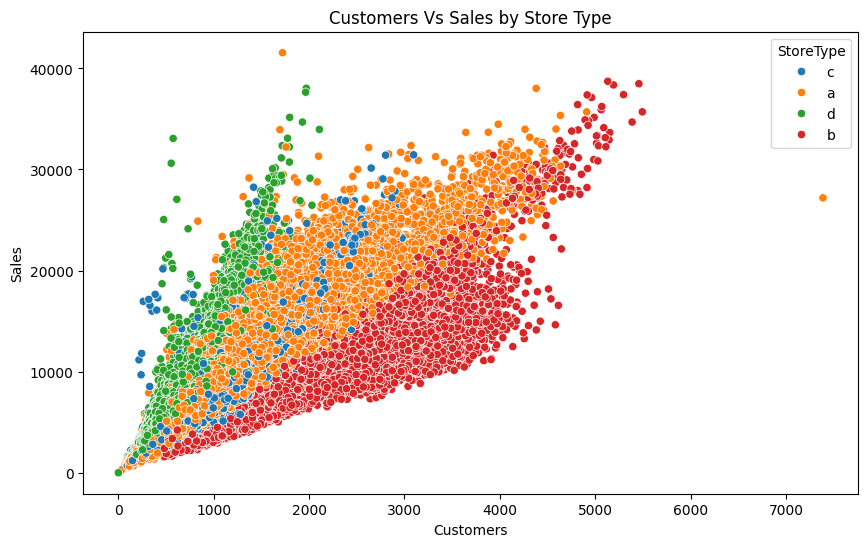

In [47]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=train_store, x='Customers', y='Sales', hue='StoreType')
plt.xlabel("Customers")
plt.ylabel("Sales")
plt.title("Customers Vs Sales by Store Type")
plt.show()

In [50]:
sales_storetype = train_store.groupby('StoreType')['Sales'].sum().sort_index(ascending=True).reset_index()
sales_storetype_mean = train_store.groupby('StoreType')['Sales'].mean().sort_index(ascending=True).reset_index()

In [51]:
print(f"Total Sales for Each Store Type:\n{sales_storetype.sort_values(by='Sales', ascending=False)}")
print("-"*50)
print(f"Average Sales for Each Store Type:\n{sales_storetype_mean.sort_values(by='Sales', ascending=False)}")

Total Sales for Each Store Type:
  StoreType       Sales
0         a  3165334859
3         d  1765392943
2         c   783221426
1         b   159231395
--------------------------------------------------
Average Sales for Each Store Type:
  StoreType         Sales
1         b  10231.407505
2         c   6932.512755
0         a   6925.167661
3         d   6822.141881


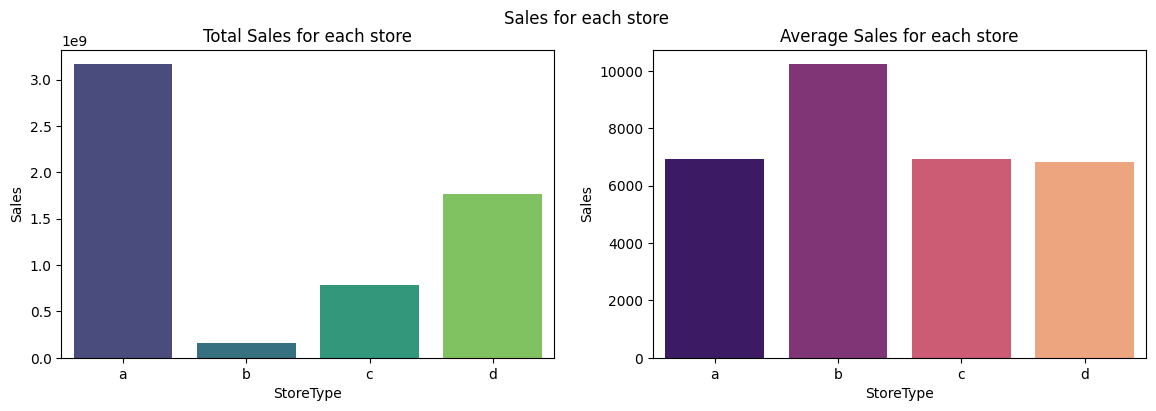

In [52]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
sns.barplot(data=sales_storetype, x='StoreType', y='Sales', palette='viridis')
plt.title("Total Sales for each store")

plt.subplot(1, 2, 2)
sns.barplot(data=sales_storetype_mean, x='StoreType', y='Sales', palette='magma')
plt.title("Average Sales for each store")

plt.suptitle("Sales for each store")
plt.show()

In [53]:
total_customers_storetype = train_store.groupby('StoreType')['Customers'].sum().sort_index().reset_index()
Avg_customers_storetype = train_store.groupby('StoreType')['Customers'].mean().sort_index().reset_index()

In [54]:
print(f"Total Customers for Each Store Type:\n{total_customers_storetype.sort_values(by='Customers', ascending=False)}")
print("-"*50)
print(f"Average Customers for Each Store Type:\n{Avg_customers_storetype.sort_values(by='Customers', ascending=False)}")

Total Customers for Each Store Type:
  StoreType  Customers
0         a  363541434
3         d  156904995
2         c   92129705
1         b   31465621
--------------------------------------------------
Average Customers for Each Store Type:
  StoreType    Customers
1         b  2021.822335
2         c   815.465887
0         a   795.361469
3         d   606.339876


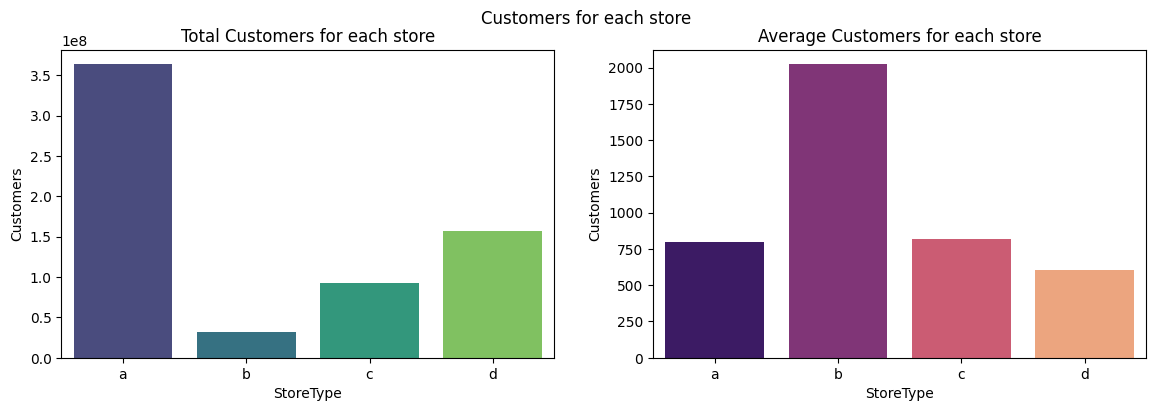

In [55]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
sns.barplot(data=total_customers_storetype, x='StoreType', y='Customers', palette='viridis')
plt.title("Total Customers for each store")

plt.subplot(1, 2, 2)
sns.barplot(data=Avg_customers_storetype, x='StoreType', y='Customers', palette='magma')
plt.title("Average Customers for each store")

plt.suptitle("Customers for each store")
plt.show()

In [56]:
total_sales_year = train_store.groupby(['StoreType', 'Year'])['Sales'].sum().reset_index()
Avg_sales_year = train_store.groupby(['StoreType', 'Year'])['Sales'].mean().reset_index()

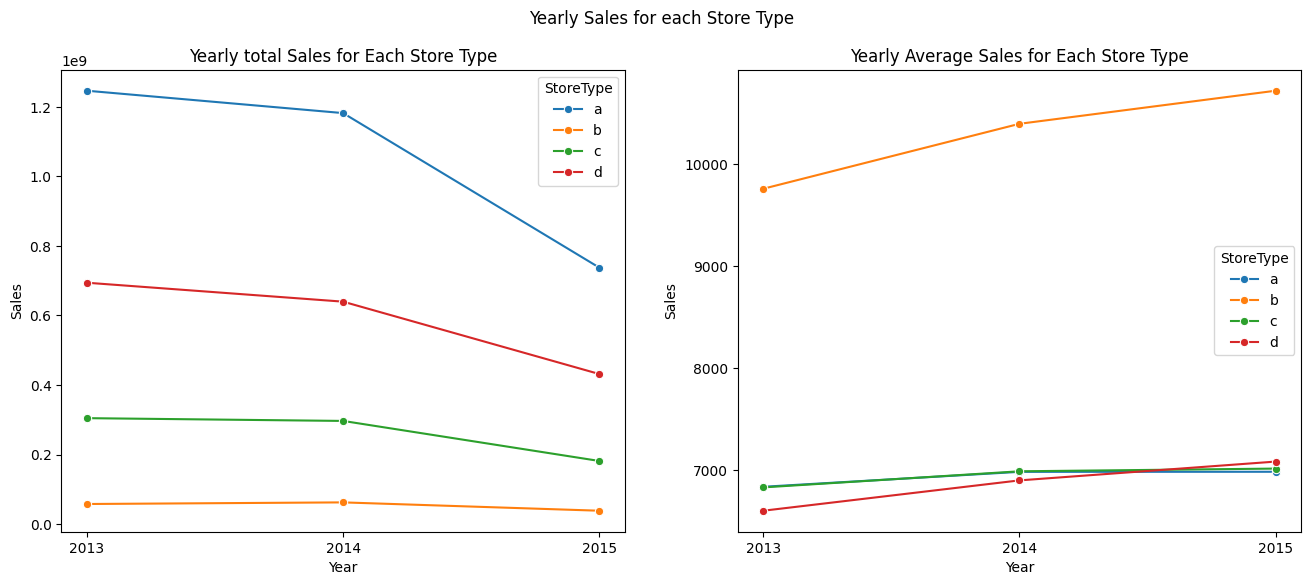

In [57]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=total_sales_year, x='Year', y='Sales', hue='StoreType', marker='o')
plt.xticks(total_sales_year['Year'].unique())
plt.title("Yearly total Sales for Each Store Type")

plt.subplot(1, 2, 2)
sns.lineplot(data=Avg_sales_year, x='Year', y='Sales', hue='StoreType', marker='o')
plt.xticks(Avg_sales_year['Year'].unique())
plt.title("Yearly Average Sales for Each Store Type")

plt.suptitle("Yearly Sales for each Store Type")
plt.show()

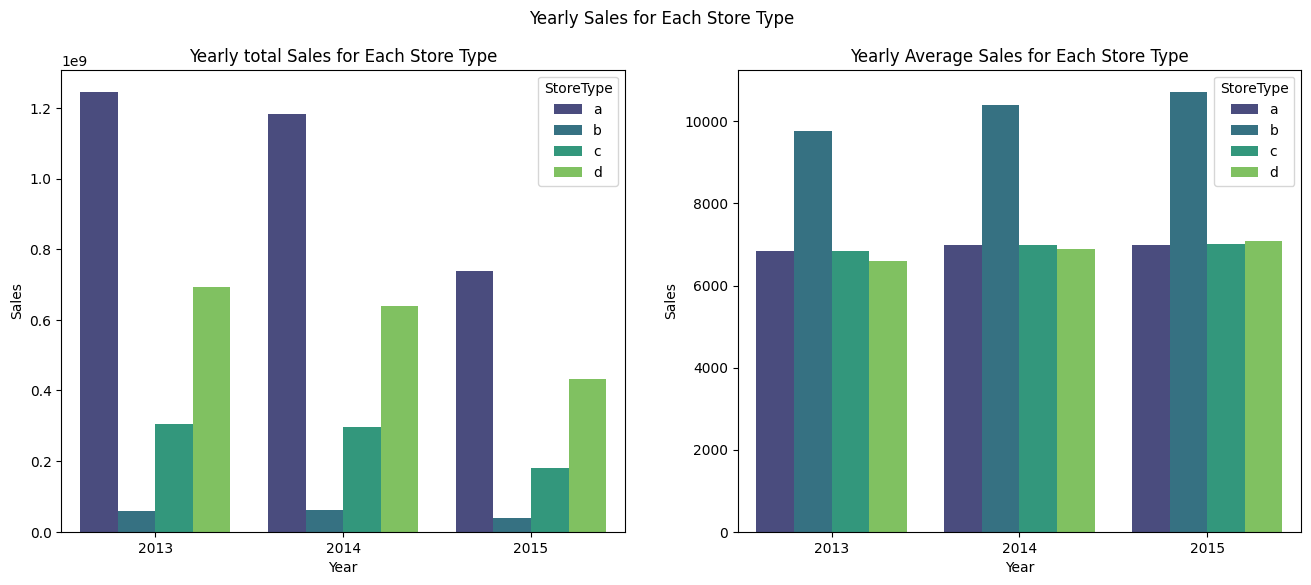

In [58]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=total_sales_year, x='Year', y='Sales', hue='StoreType', palette='viridis')
plt.title("Yearly total Sales for Each Store Type")

plt.subplot(1, 2, 2)
sns.barplot(data=Avg_sales_year, x='Year', y='Sales', hue='StoreType', palette='viridis')
plt.title("Yearly Average Sales for Each Store Type")

plt.suptitle("Yearly Sales for Each Store Type")
plt.show()

<Figure size 1000x500 with 0 Axes>

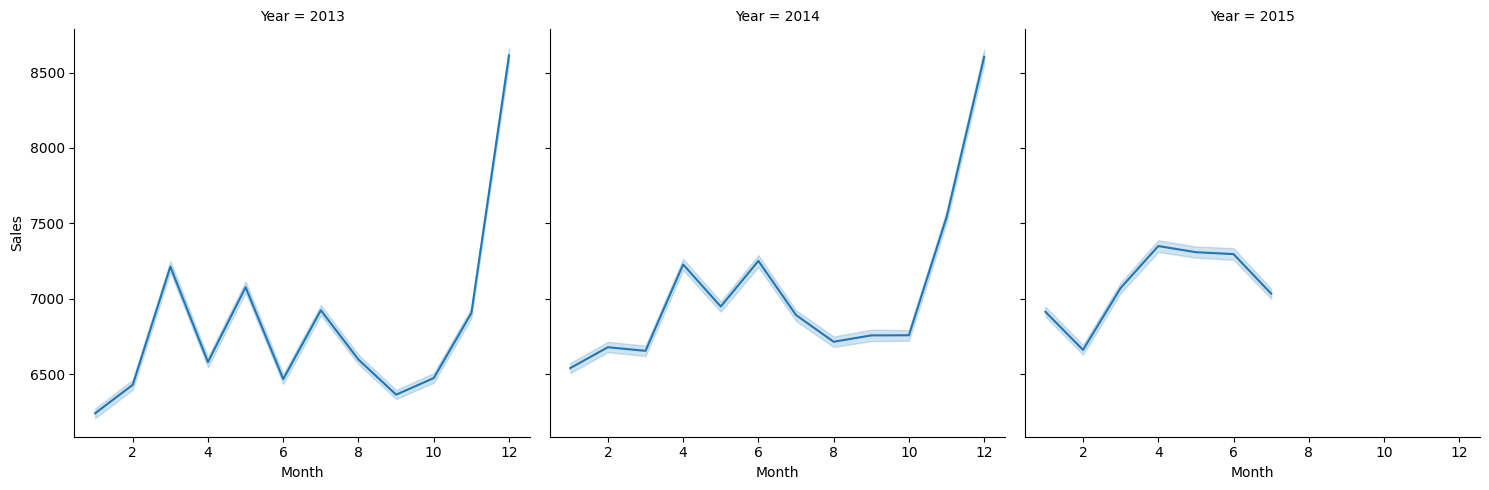

In [59]:
plt.figure(figsize=(10, 5))
sns.relplot(data=train_store, x='Month', y='Sales', col='Year', palette='husl', kind='line')
plt.show()

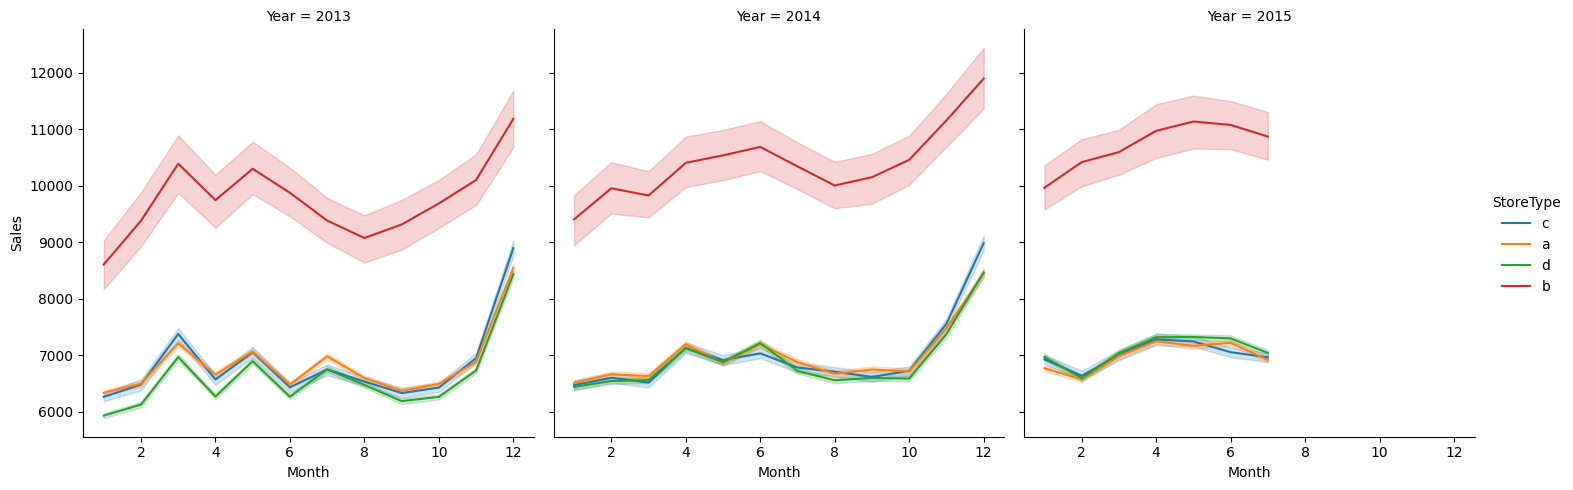

In [60]:
sns.relplot(
    data=train_store,
    x='Month',
    y='Sales',
    hue='StoreType',
    col='Year',
    kind='line',
    col_wrap=3
)

<Axes: xlabel='Day', ylabel='Customers'>

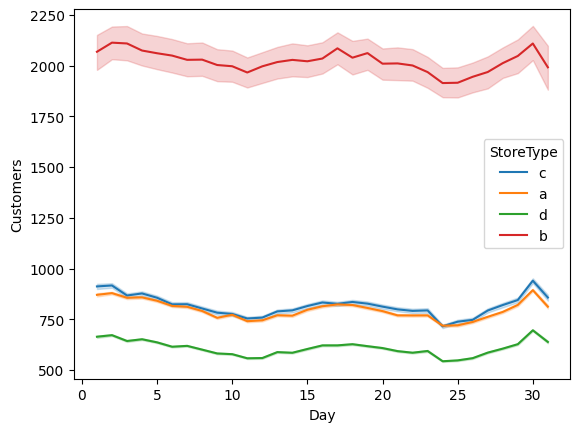

In [61]:
sns.lineplot(data=train_store, x='Day', y='Customers', hue='StoreType')

<Axes: xlabel='Day', ylabel='Customers'>

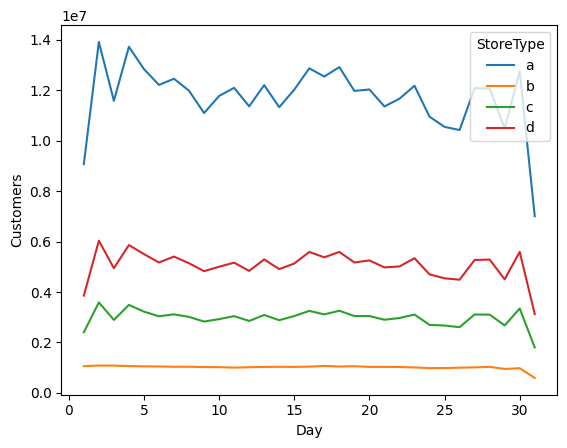

In [62]:
sns.lineplot(data=train_store.groupby(['Day', 'StoreType'])['Customers'].sum().reset_index(), x='Day', y='Customers', hue='StoreType')

In [63]:
customers_with_promo = train_store.groupby(['Promo', 'StoreType'])['Customers'].mean().reset_index()
customers_with_promo2 = train_store.groupby(['Promo2', 'StoreType'])['Customers'].mean().reset_index()

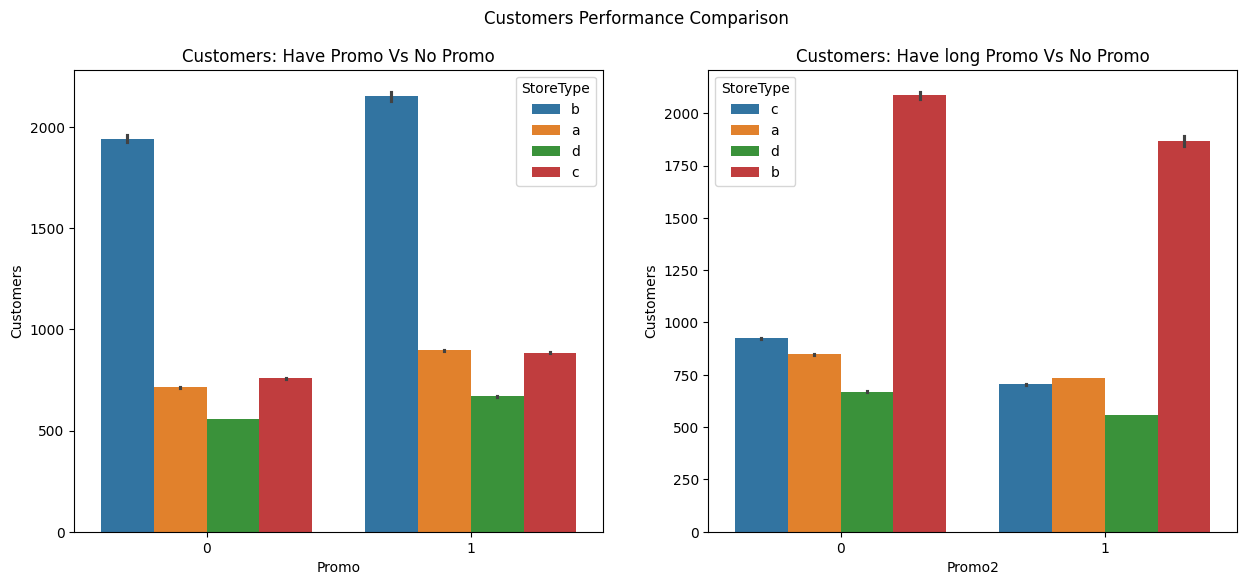

In [64]:
plt.figure(figsize=(15,6))

plt.subplot(1, 2, 1)
sns.barplot(data=train_store, x='Promo', y='Customers', hue='StoreType')
plt.title("Customers: Have Promo Vs No Promo")

plt.subplot(1, 2, 2)
sns.barplot(data=train_store, x='Promo2', y='Customers', hue='StoreType')
plt.title("Customers: Have long Promo Vs No Promo")

plt.suptitle("Customers Performance Comparison")
plt.show()

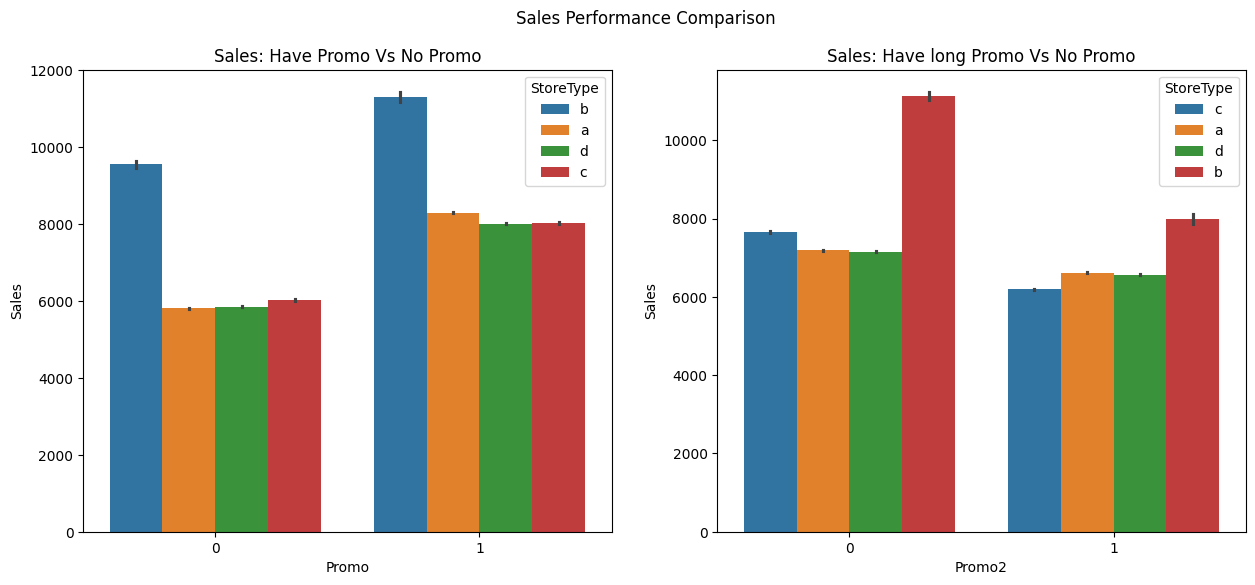

In [65]:
plt.figure(figsize=(15,6))

plt.subplot(1, 2, 1)
sns.barplot(data=train_store, x='Promo', y='Sales', hue='StoreType')
plt.title("Sales: Have Promo Vs No Promo")

plt.subplot(1, 2, 2)
sns.barplot(data=train_store, x='Promo2', y='Sales', hue='StoreType')
plt.title("Sales: Have long Promo Vs No Promo")

plt.suptitle("Sales Performance Comparison")
plt.show()

In [66]:
promo_sales = train_store.groupby('Promo')['Sales'].mean().reset_index()
promo_cust = train_store.groupby('Promo')['Customers'].mean().reset_index()

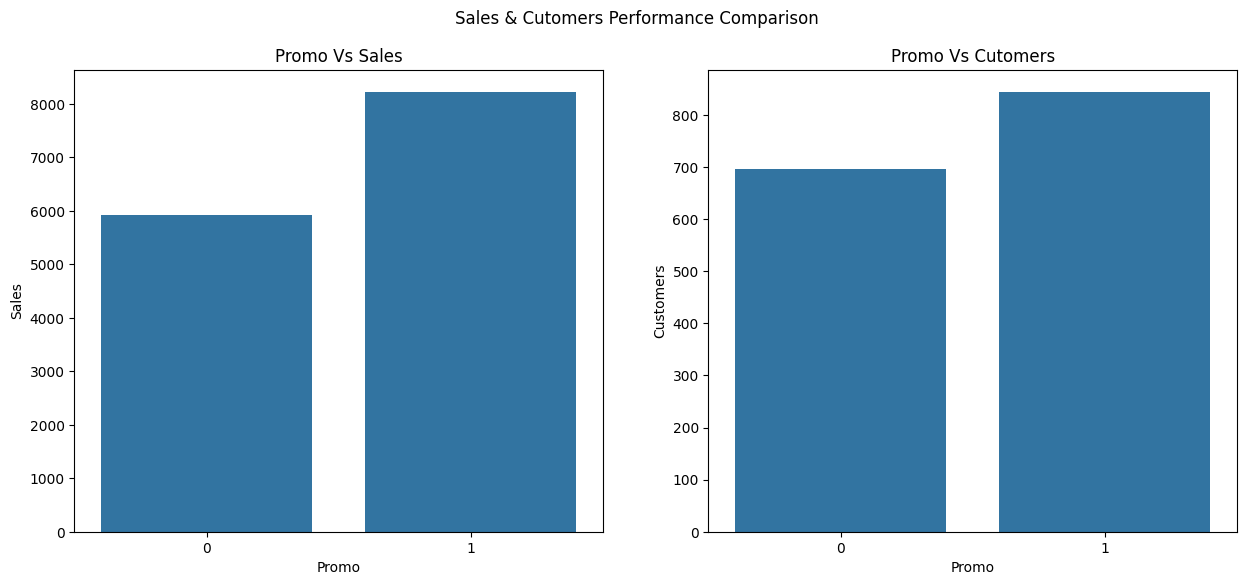

In [67]:
plt.figure(figsize=(15,6))

plt.subplot(1, 2, 1)
sns.barplot(data=promo_sales, x='Promo', y='Sales')
plt.title("Promo Vs Sales")

plt.subplot(1, 2, 2)
sns.barplot(data=promo_cust, x='Promo', y='Customers')
plt.title("Promo Vs Cutomers")

plt.suptitle("Sales & Cutomers Performance Comparison")
plt.show()

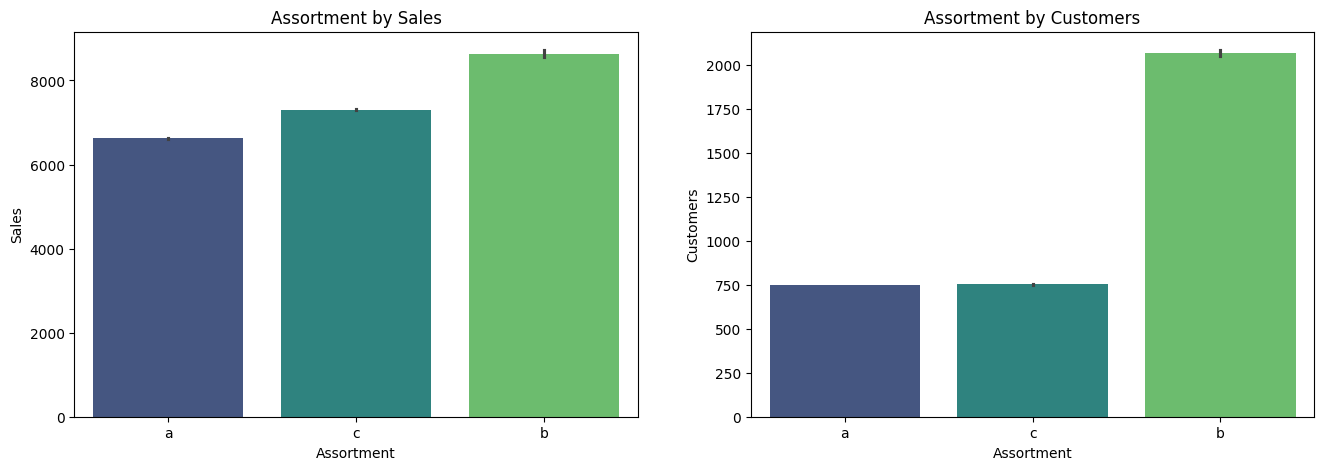

In [68]:
plt.figure(figsize=(16, 5))

plt.subplot(1,2, 1)
sns.barplot(data=train_store, x='Assortment', y='Sales',palette='viridis')
plt.title("Assortment by Sales")

plt.subplot(1, 2, 2)
sns.barplot(data=train_store, x='Assortment', y='Customers', palette='viridis')
plt.title("Assortment by Customers")

plt.show()

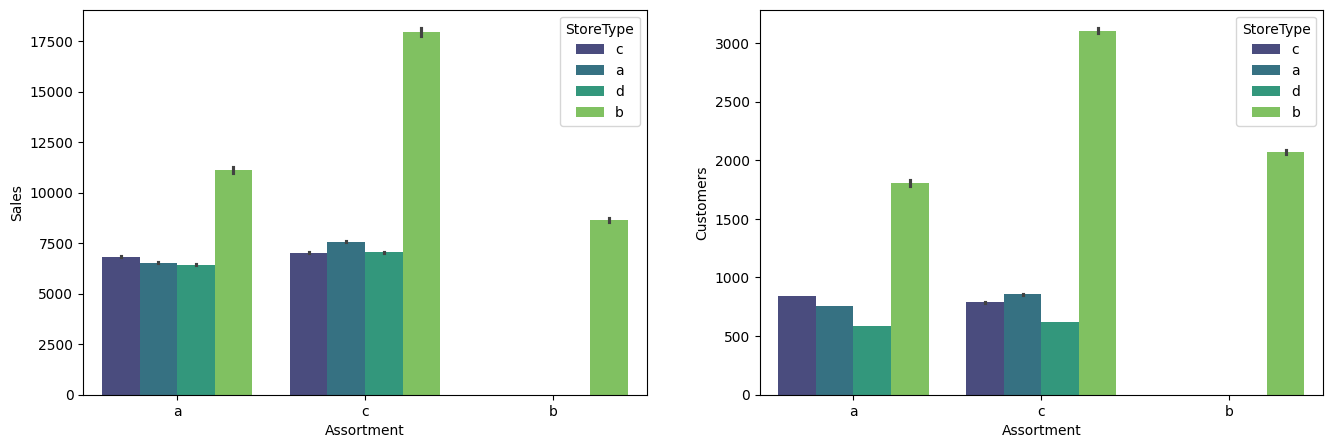

In [69]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=train_store, x='Assortment', y='Sales', hue='StoreType', palette='viridis')

plt.subplot(1, 2, 2)
sns.barplot(data=train_store, x='Assortment', y='Customers', hue='StoreType', palette='viridis')

plt.show()

In [70]:
train_store.groupby('DayOfWeek')['Sales'].mean().reset_index()

,DayOfWeek,Sales
0,1,8216.073074
1,2,7088.113656
2,3,6728.122978
3,4,6767.310159
4,5,7072.677012
5,6,5874.840238
6,7,8224.723908


In [71]:
train_store.groupby(['DayOfWeek'])['Customers'].mean().reset_index()

,DayOfWeek,Customers
0,1,855.444984
1,2,769.986753
2,3,740.598876
3,4,755.569784
4,5,781.771639
5,6,660.177526
6,7,1441.532424


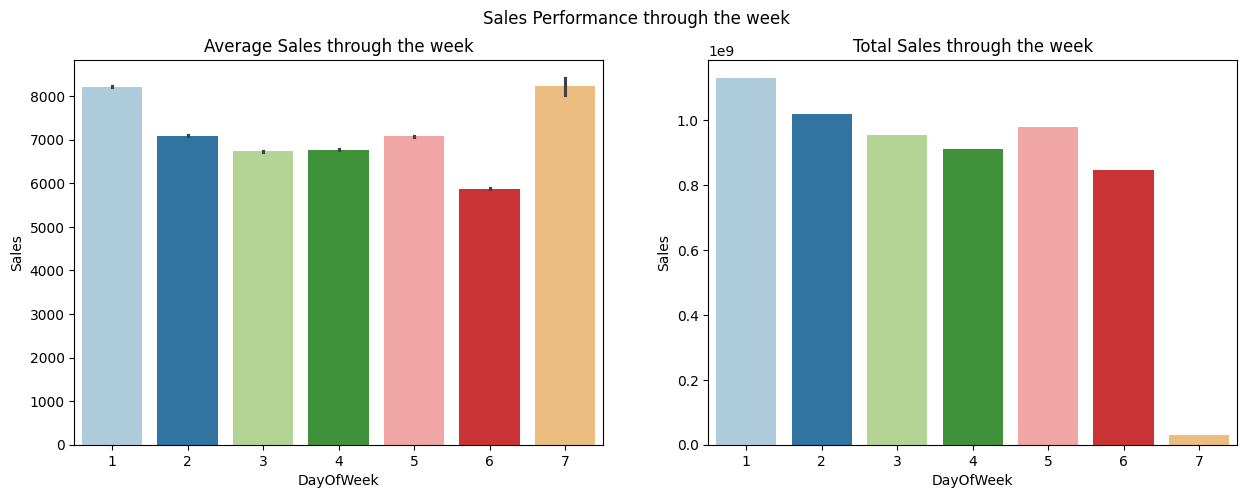

In [72]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2,  1)
sns.barplot(data=train_store, x='DayOfWeek', y='Sales', palette="Paired")
plt.title("Average Sales through the week")

plt.subplot(1, 2, 2) 
sns.barplot(data=train_store.groupby('DayOfWeek')['Sales'].sum().reset_index(), x='DayOfWeek', y='Sales', palette="Paired")
plt.title("Total Sales through the week")

plt.suptitle("Sales Performance through the week")
plt.show()

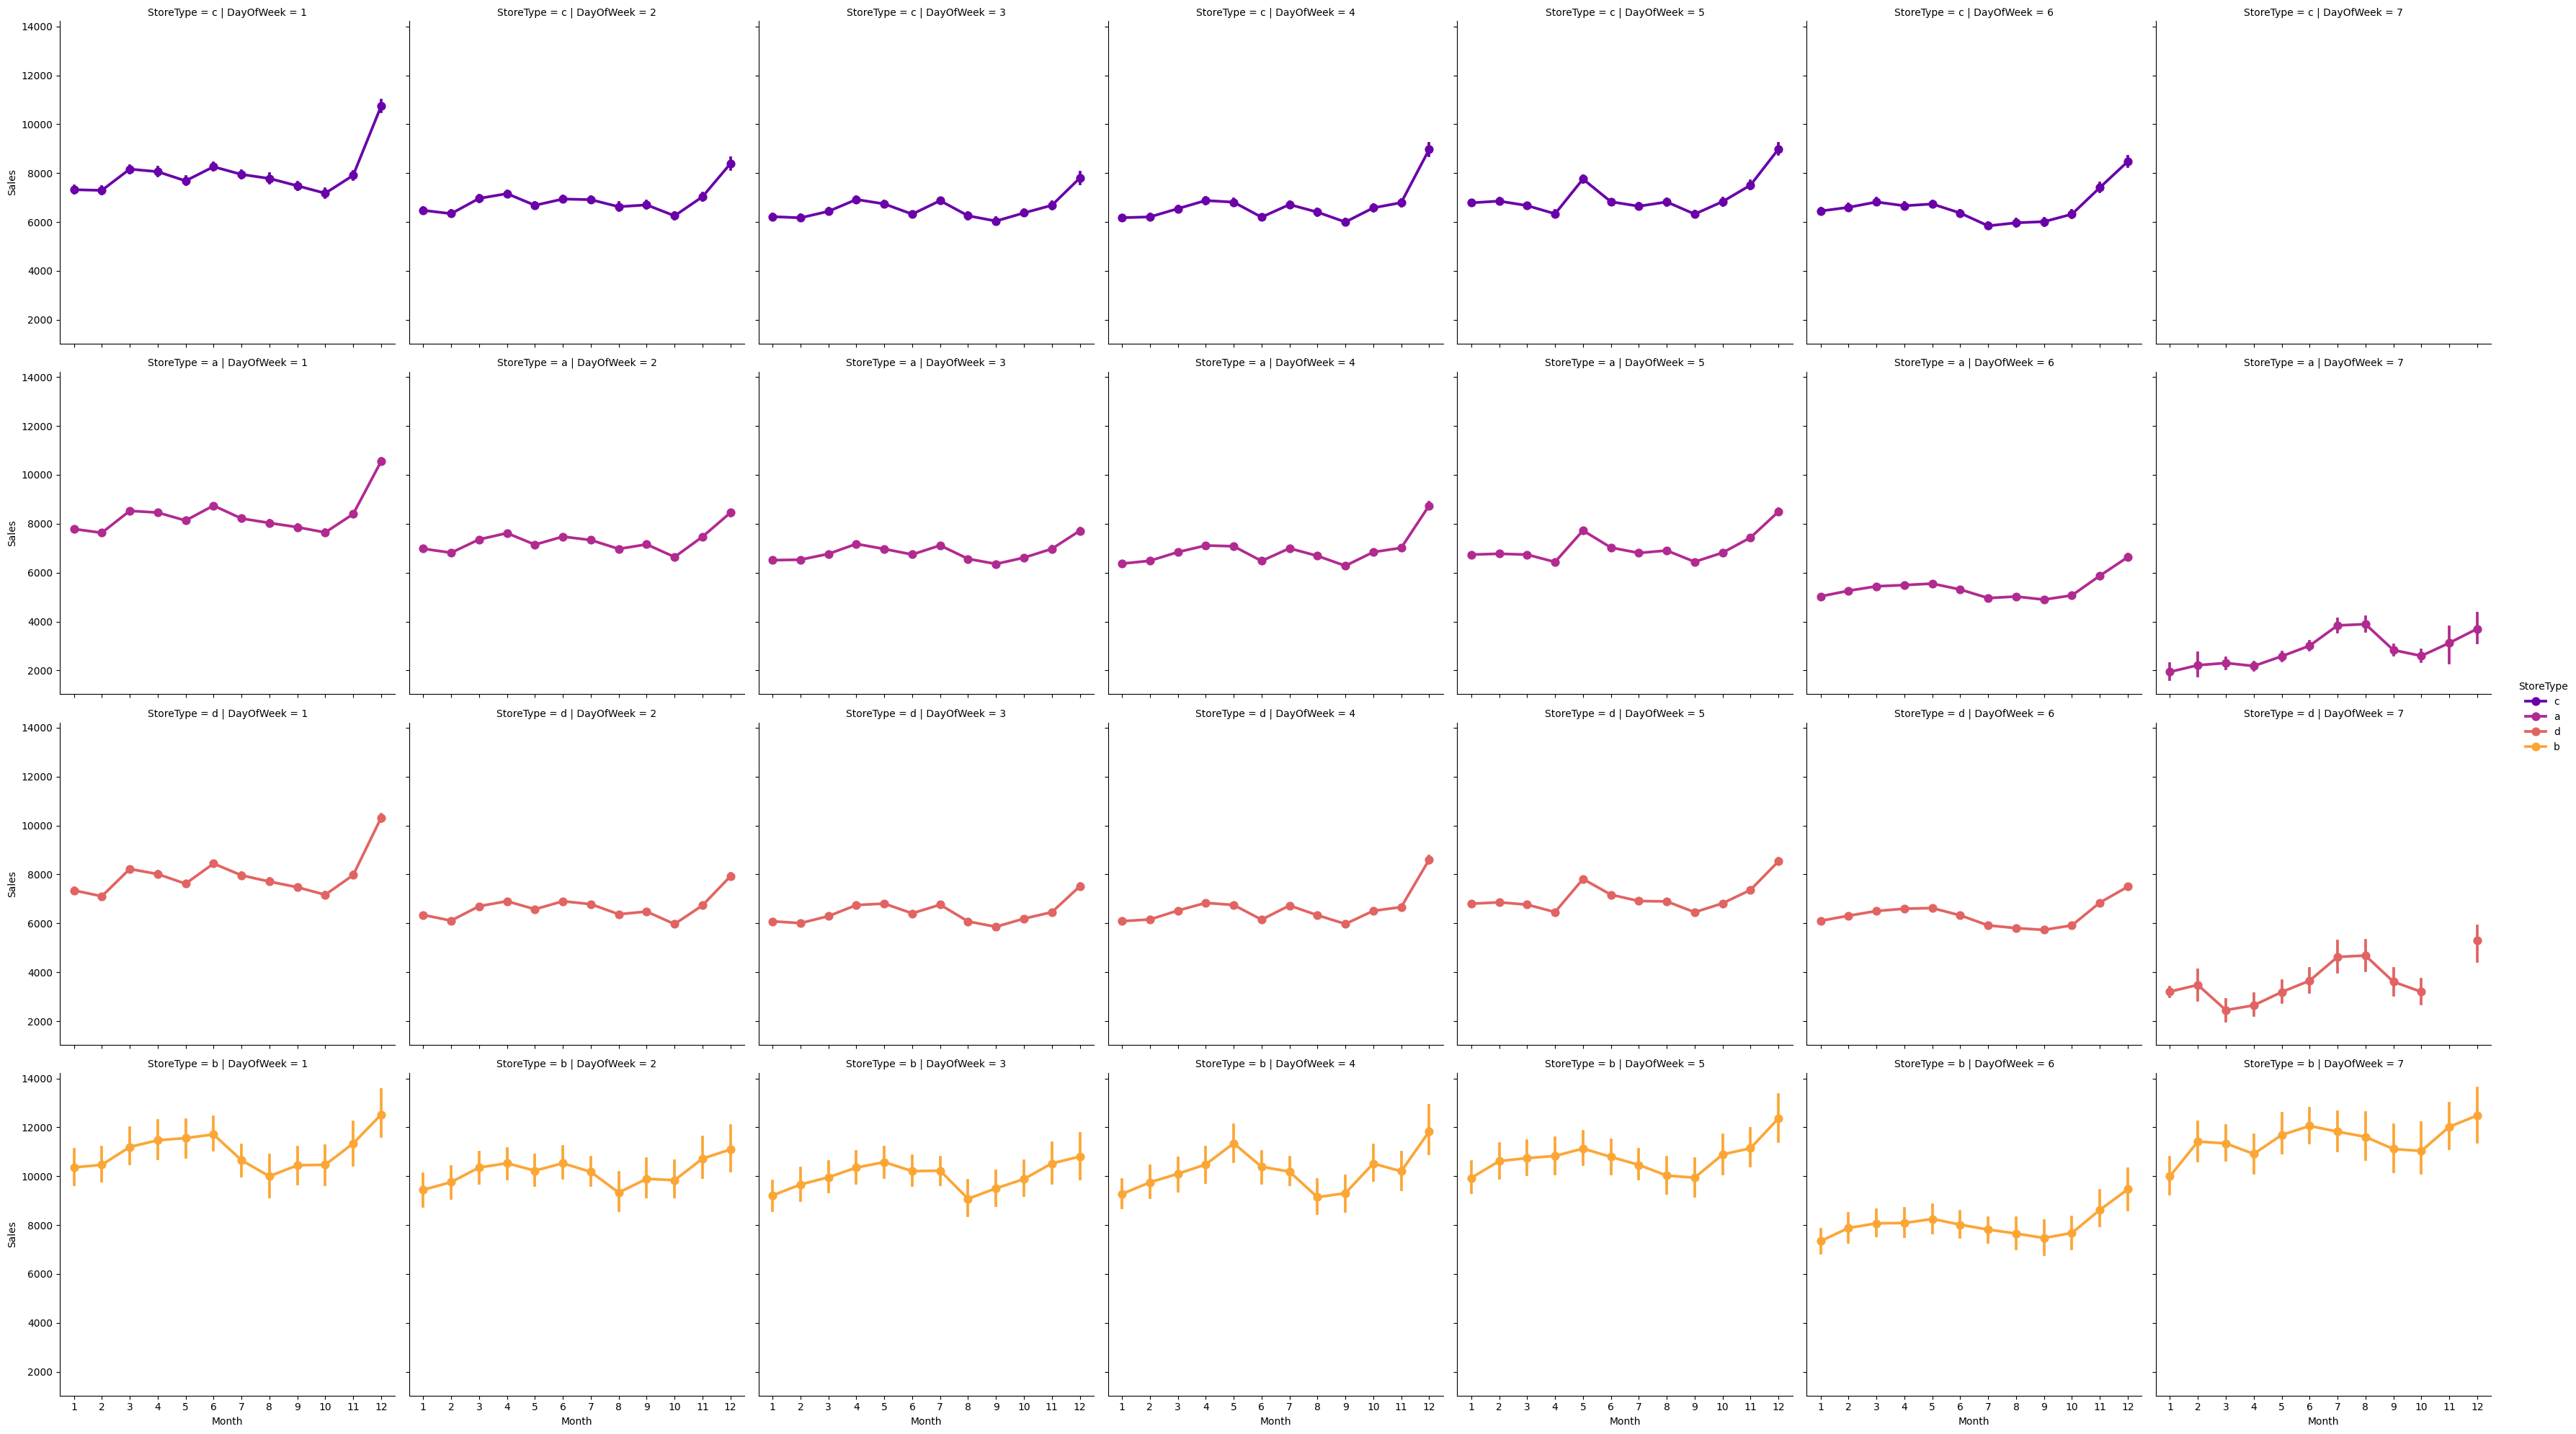

In [73]:
sns.catplot(data = train_store, 
            x = 'Month', 
            y = "Sales", 
            kind='point',
            col = 'DayOfWeek', 
            palette = 'plasma',
            hue = 'StoreType',
            row = 'StoreType') 

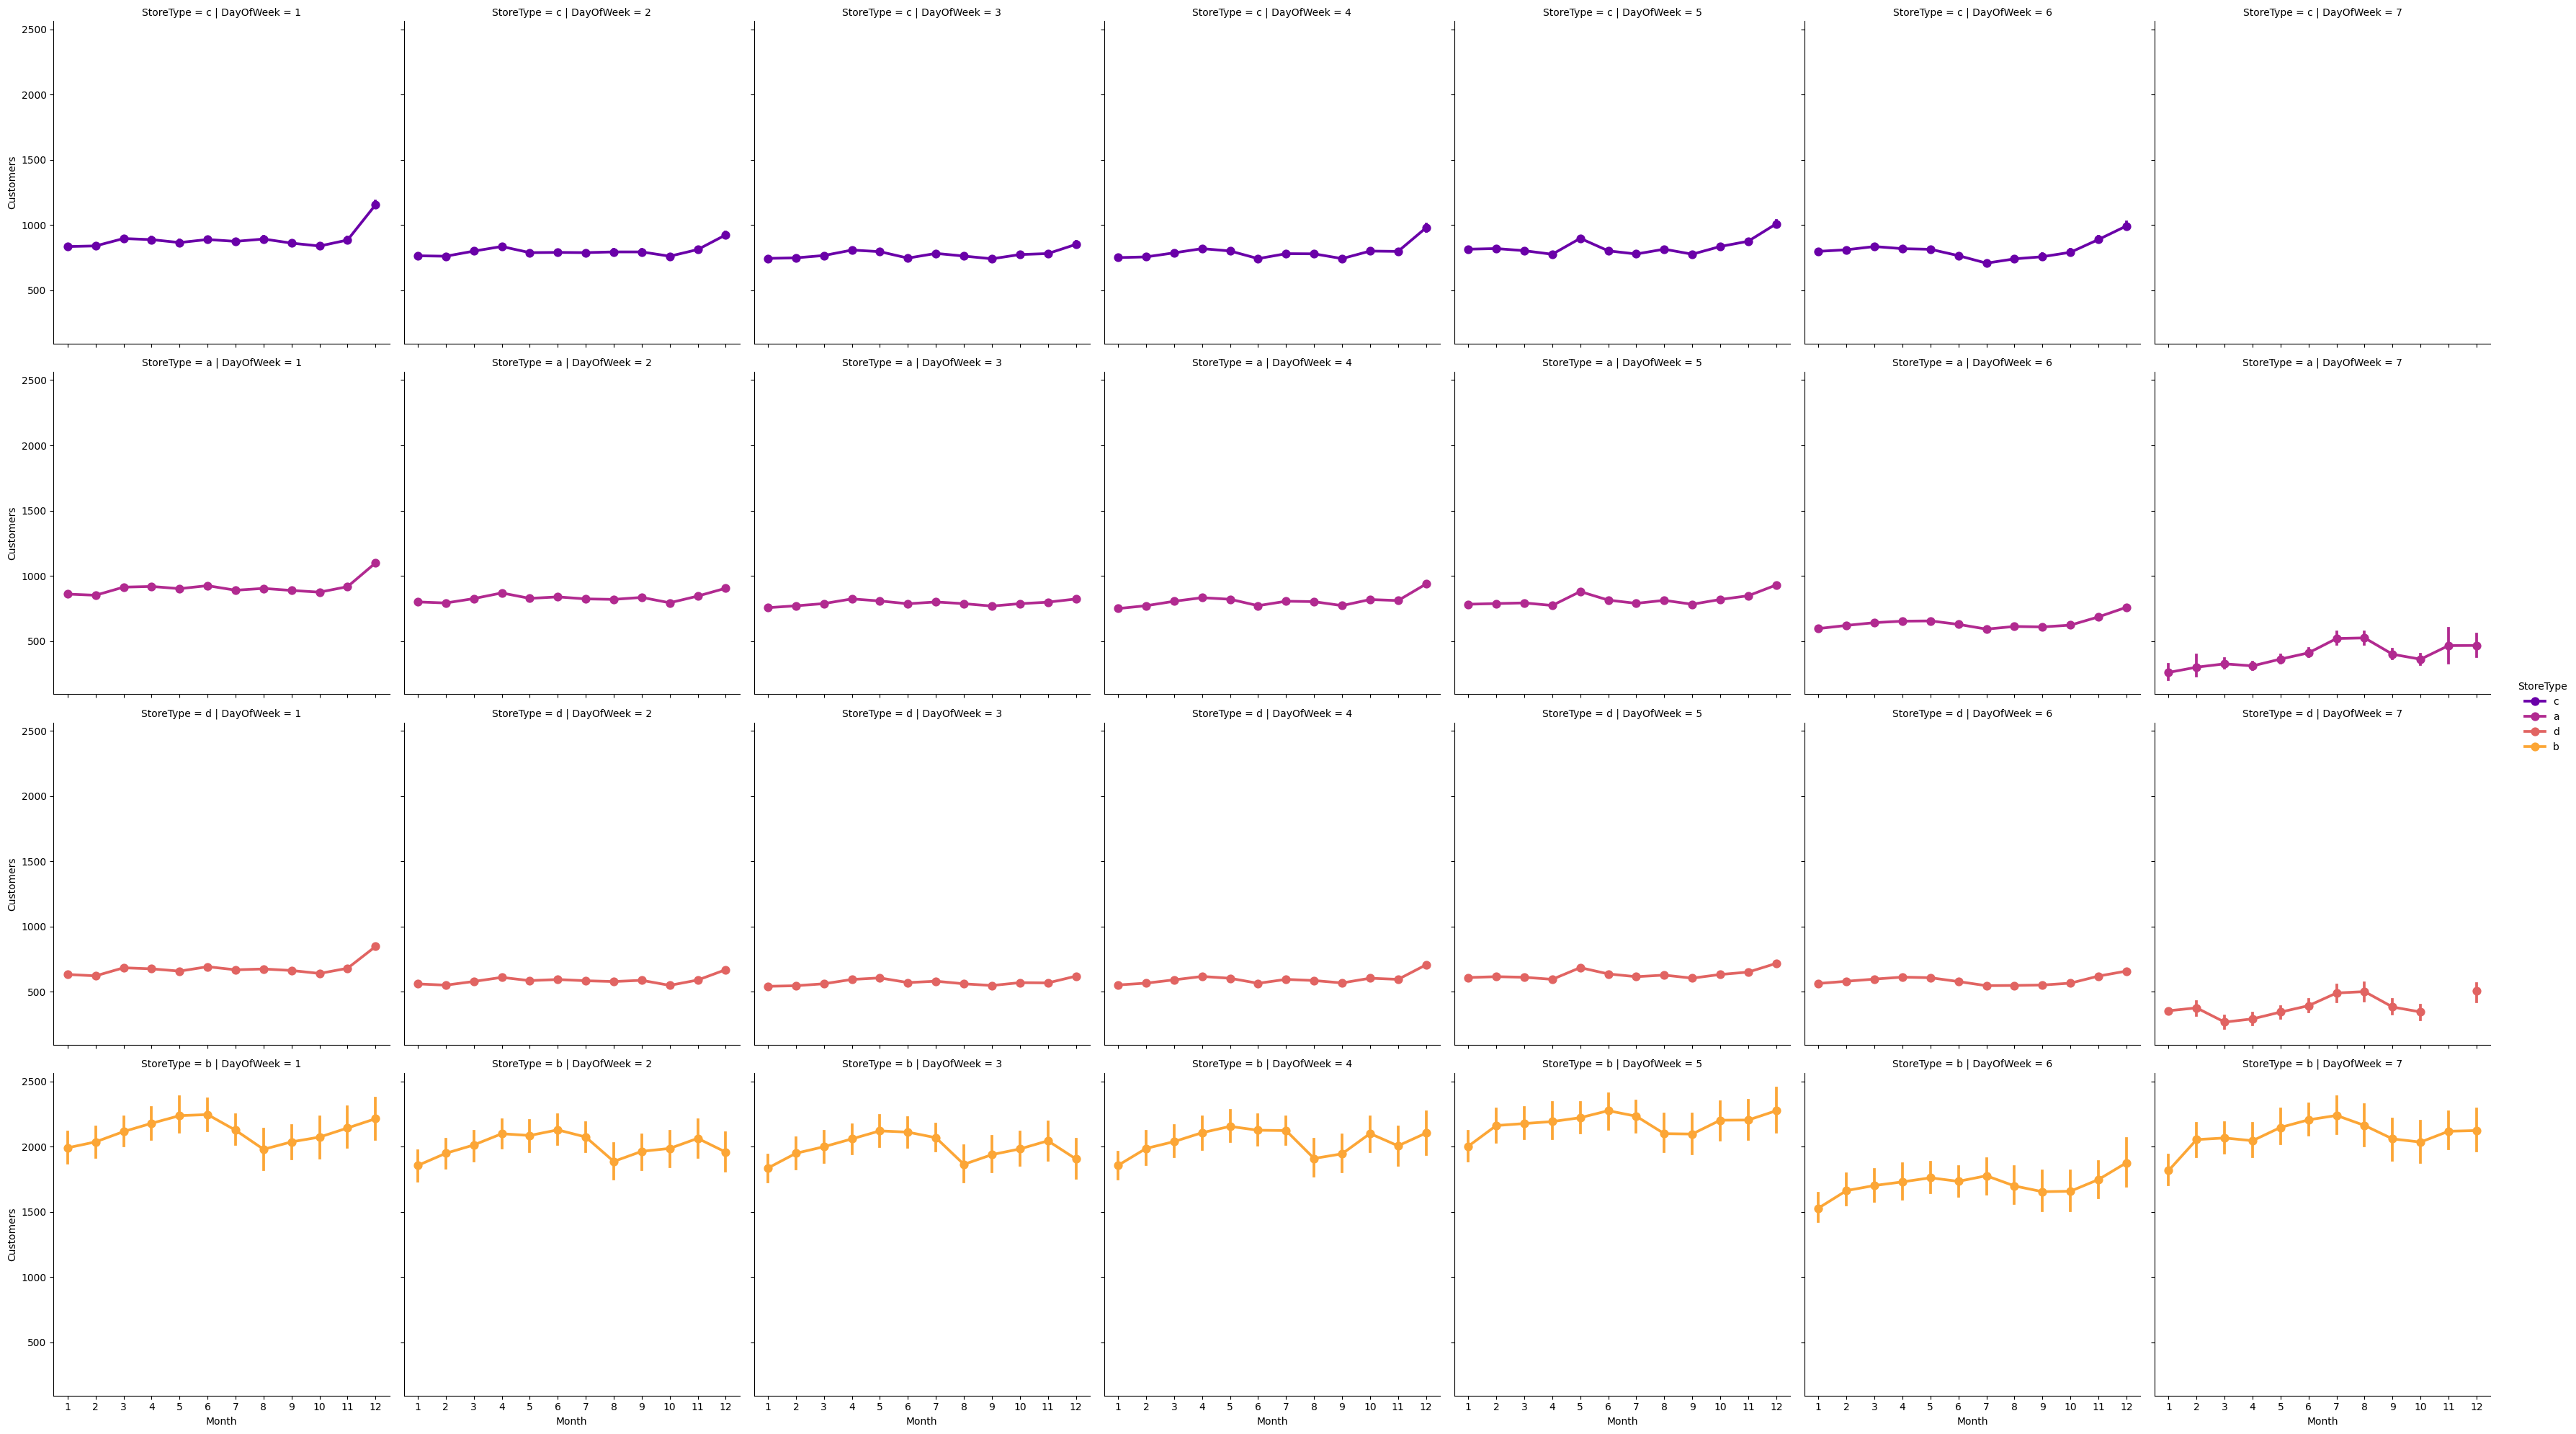

In [74]:
sns.catplot(data = train_store, 
            x = 'Month', 
            y = "Customers", 
            kind='point',
            col = 'DayOfWeek', 
            palette = 'plasma',
            hue = 'StoreType',
            row = 'StoreType') 

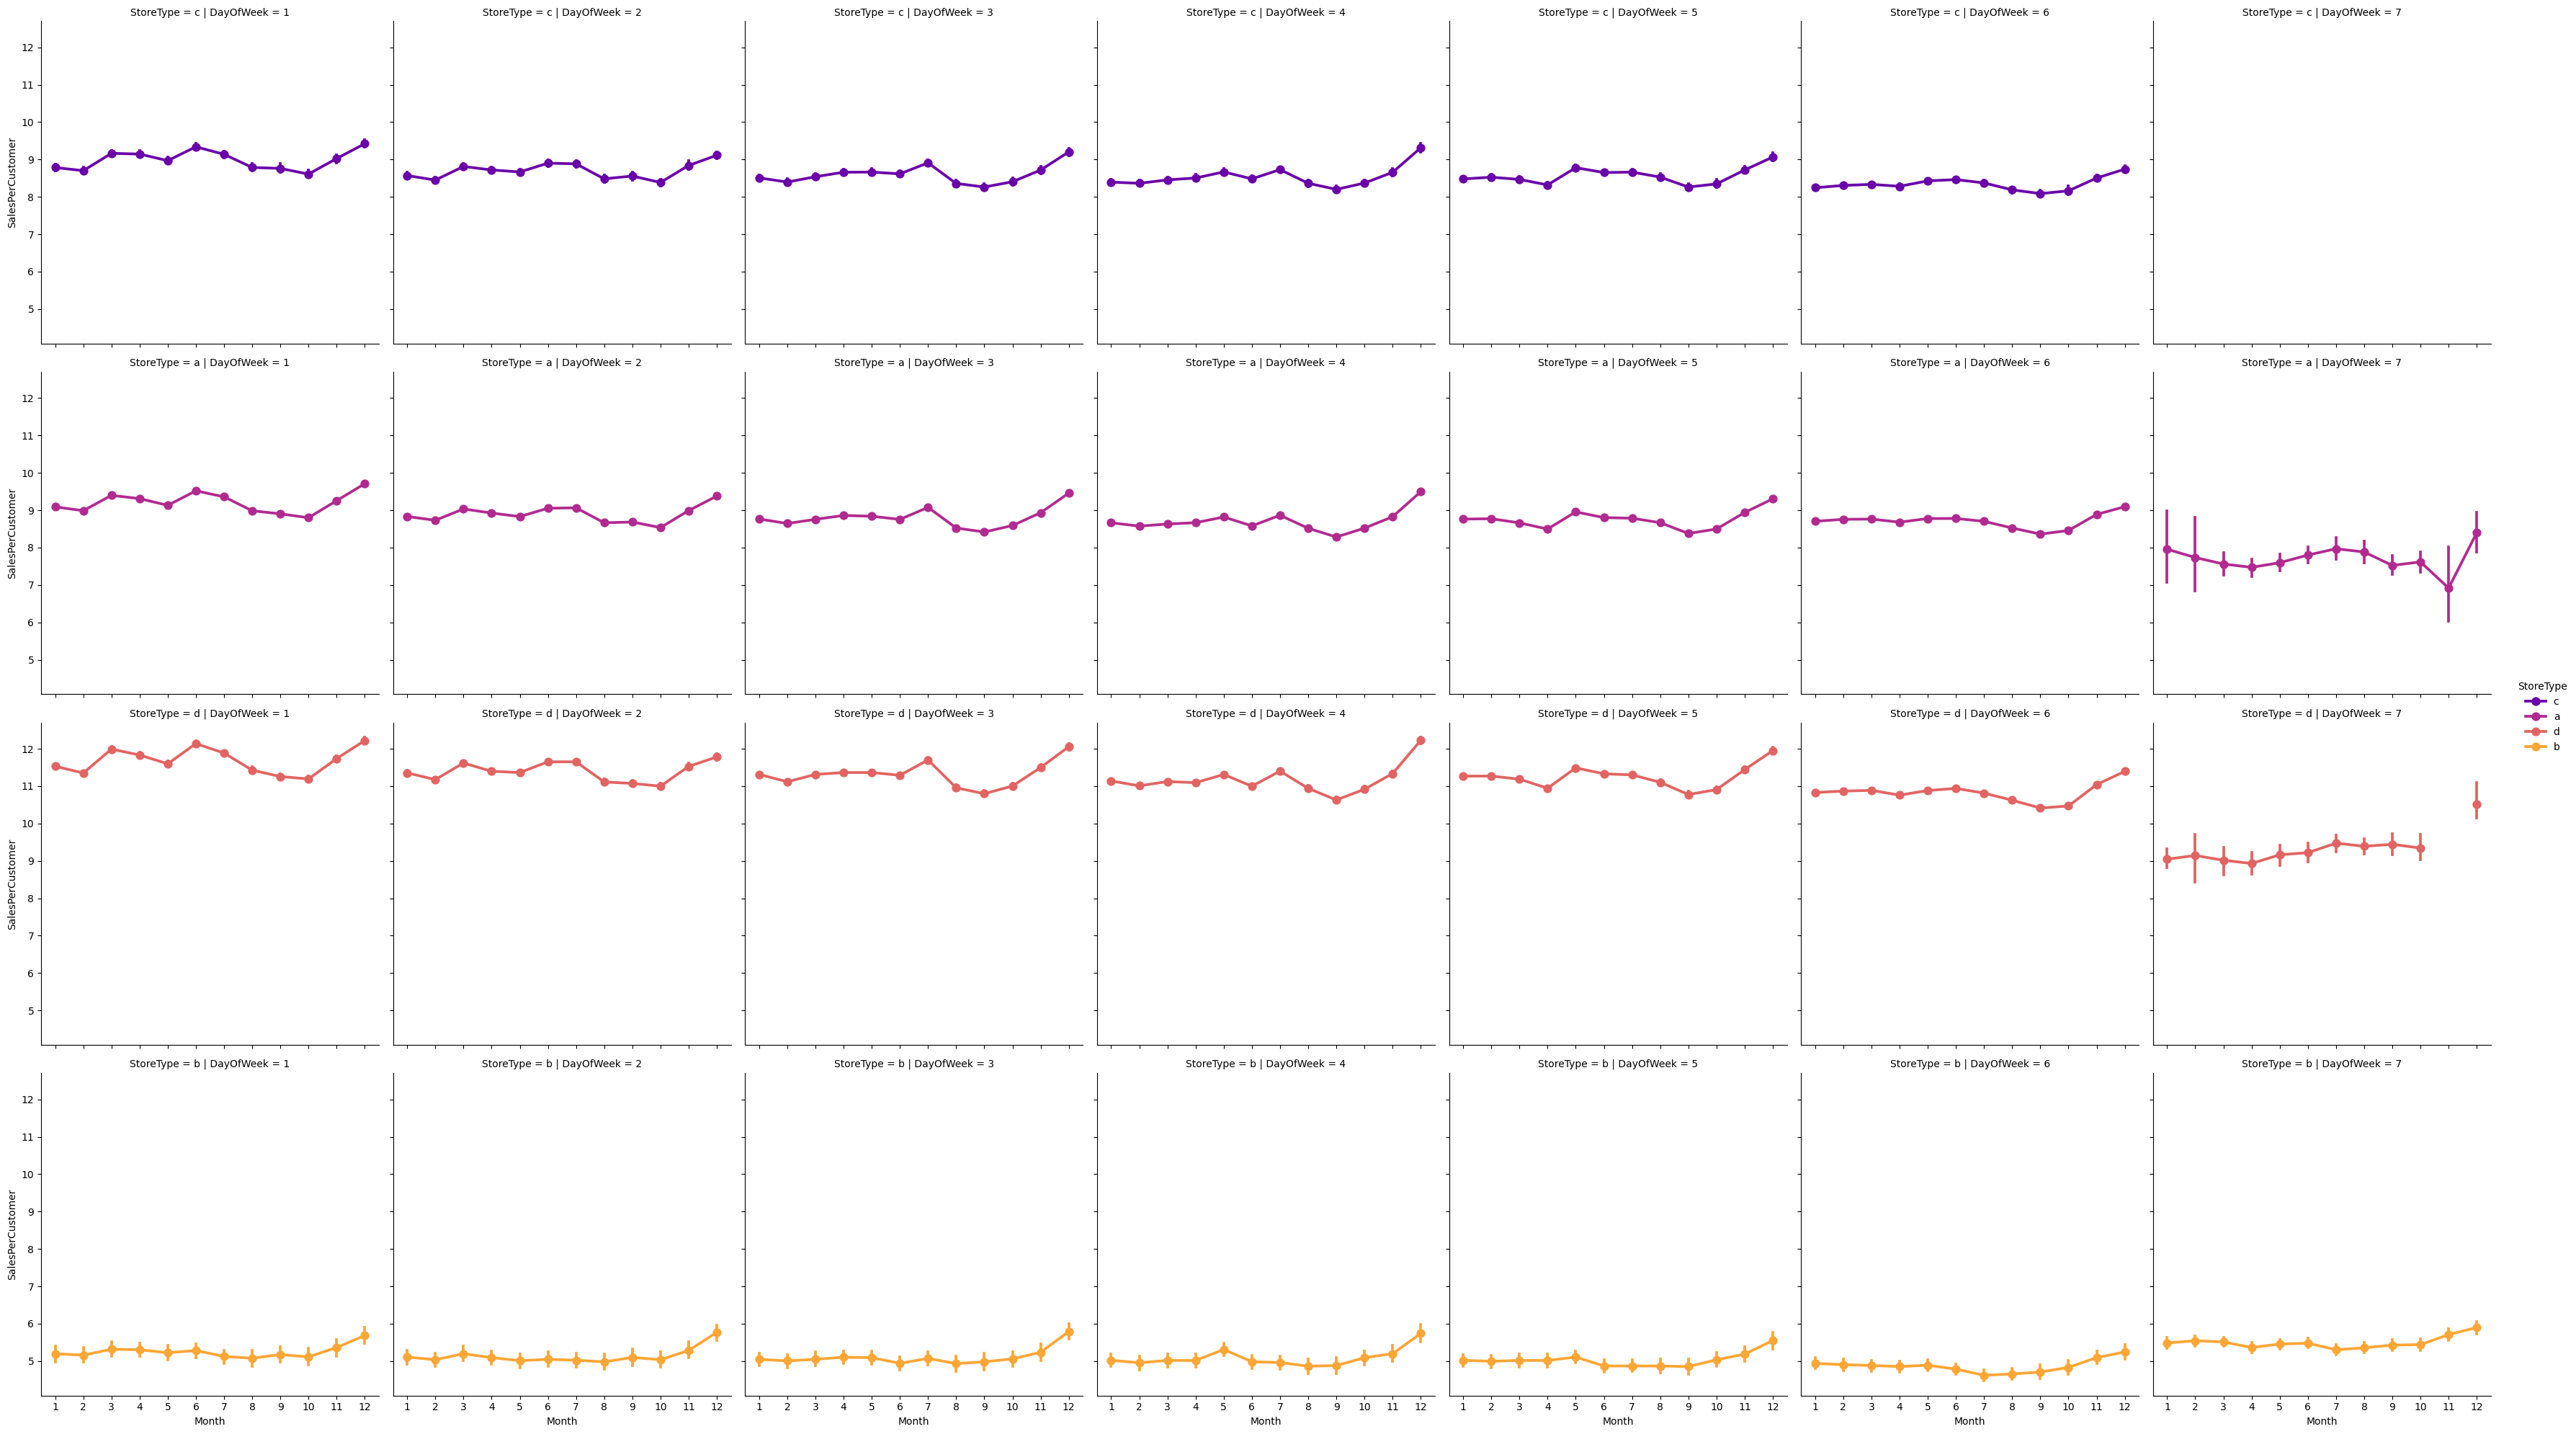

In [75]:
sns.catplot(data = train_store, 
            x = 'Month', 
            y = "SalesPerCustomer", 
            kind='point',
            col = 'DayOfWeek', 
            palette = 'plasma',
            hue = 'StoreType',
            row = 'StoreType') 

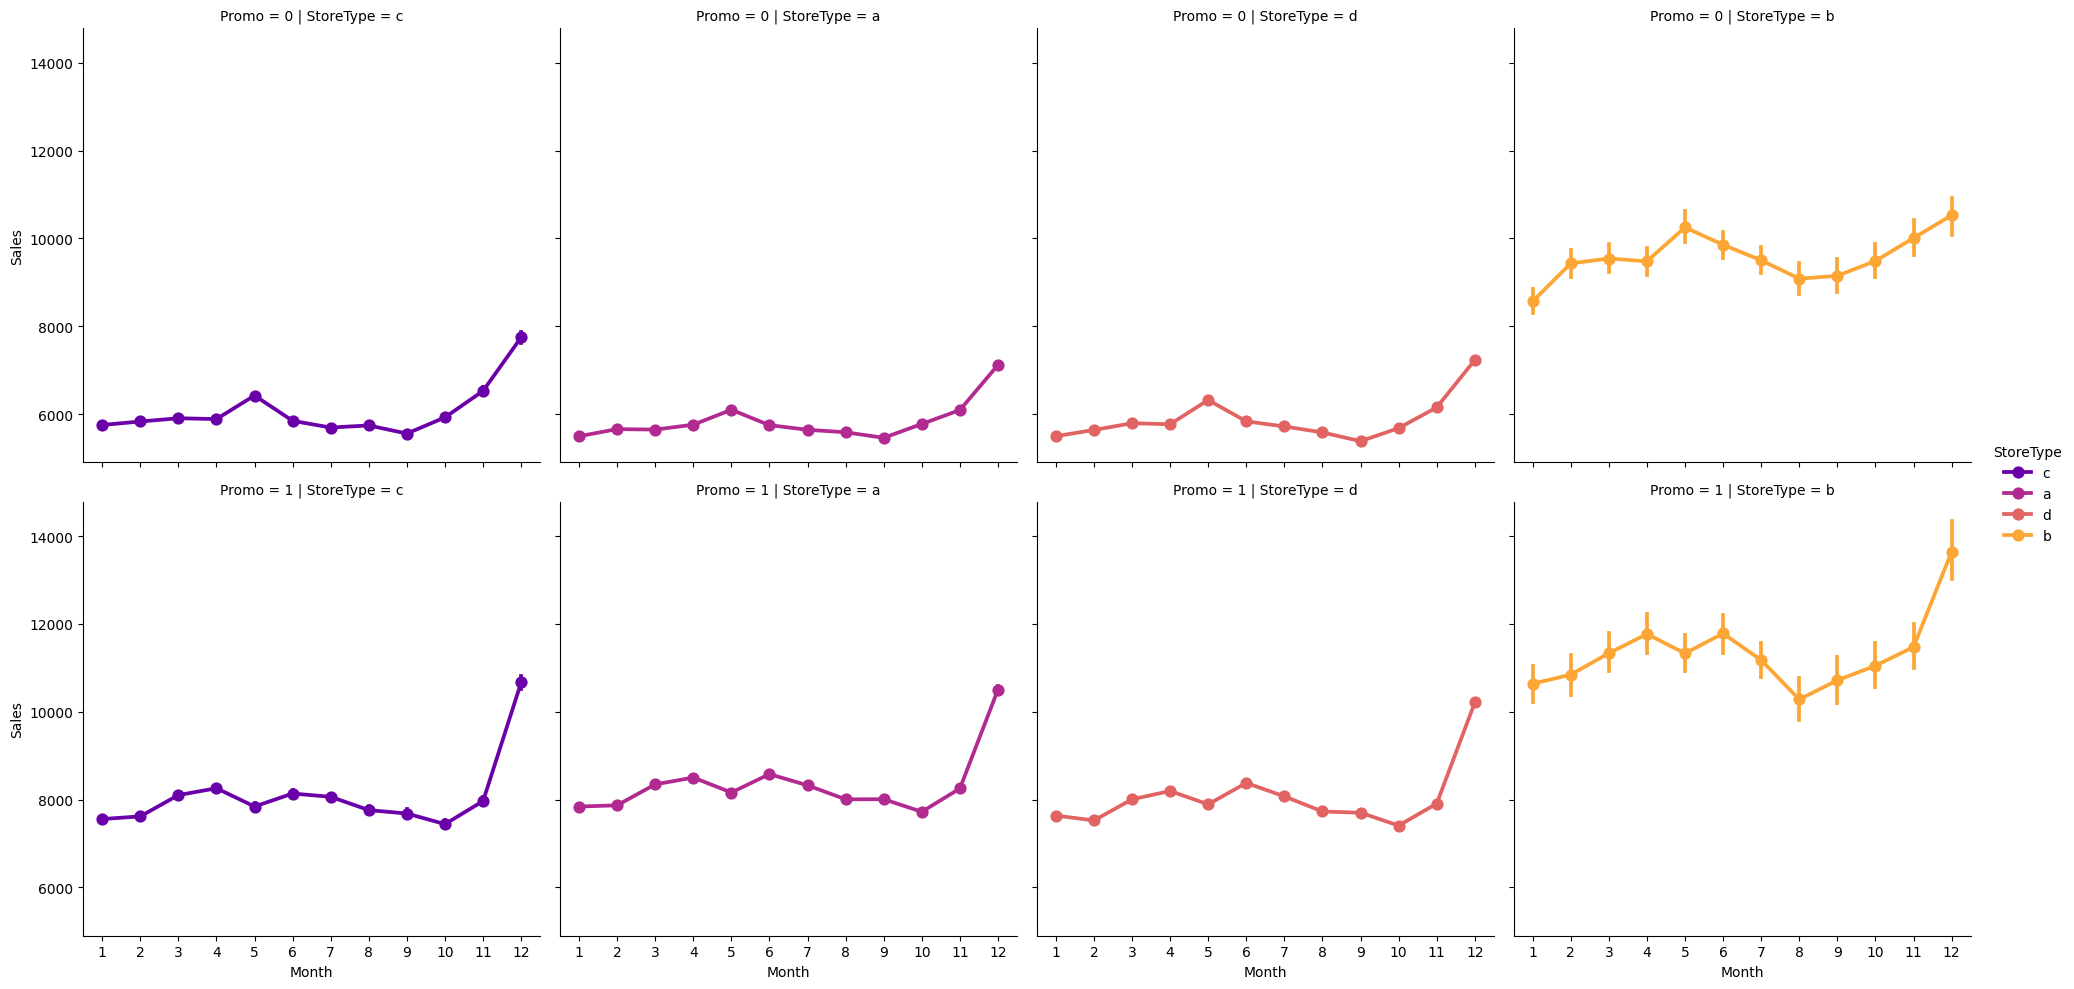

In [76]:
sns.catplot(data = train_store, 
            x = 'Month', 
            y = "Sales", 
            kind='point',
            col = 'StoreType', 
            palette = 'plasma',
            hue = 'StoreType',
            row = 'Promo') 

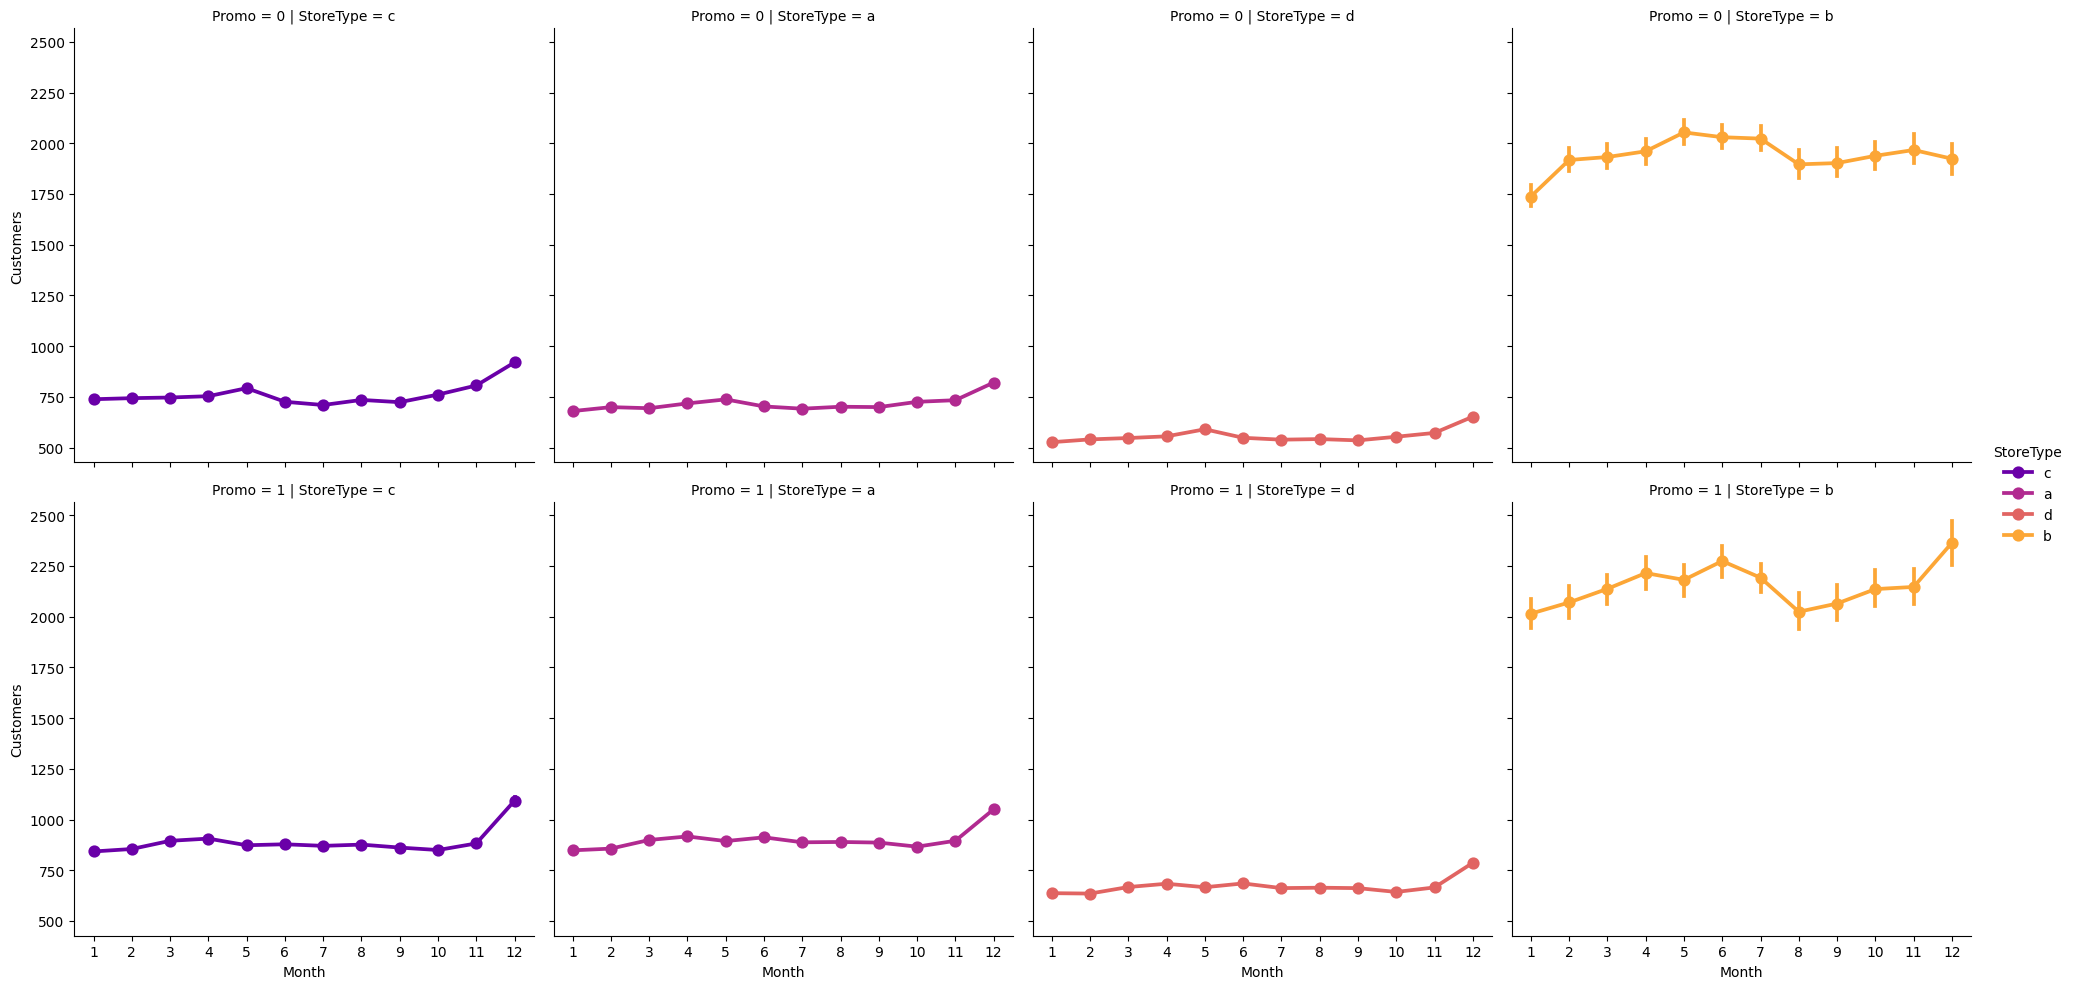

In [77]:
sns.catplot(data = train_store, 
            x = 'Month', 
            y = "Customers", 
            kind='point',
            col = 'StoreType', 
            palette = 'plasma',
            hue = 'StoreType',
            row = 'Promo') 

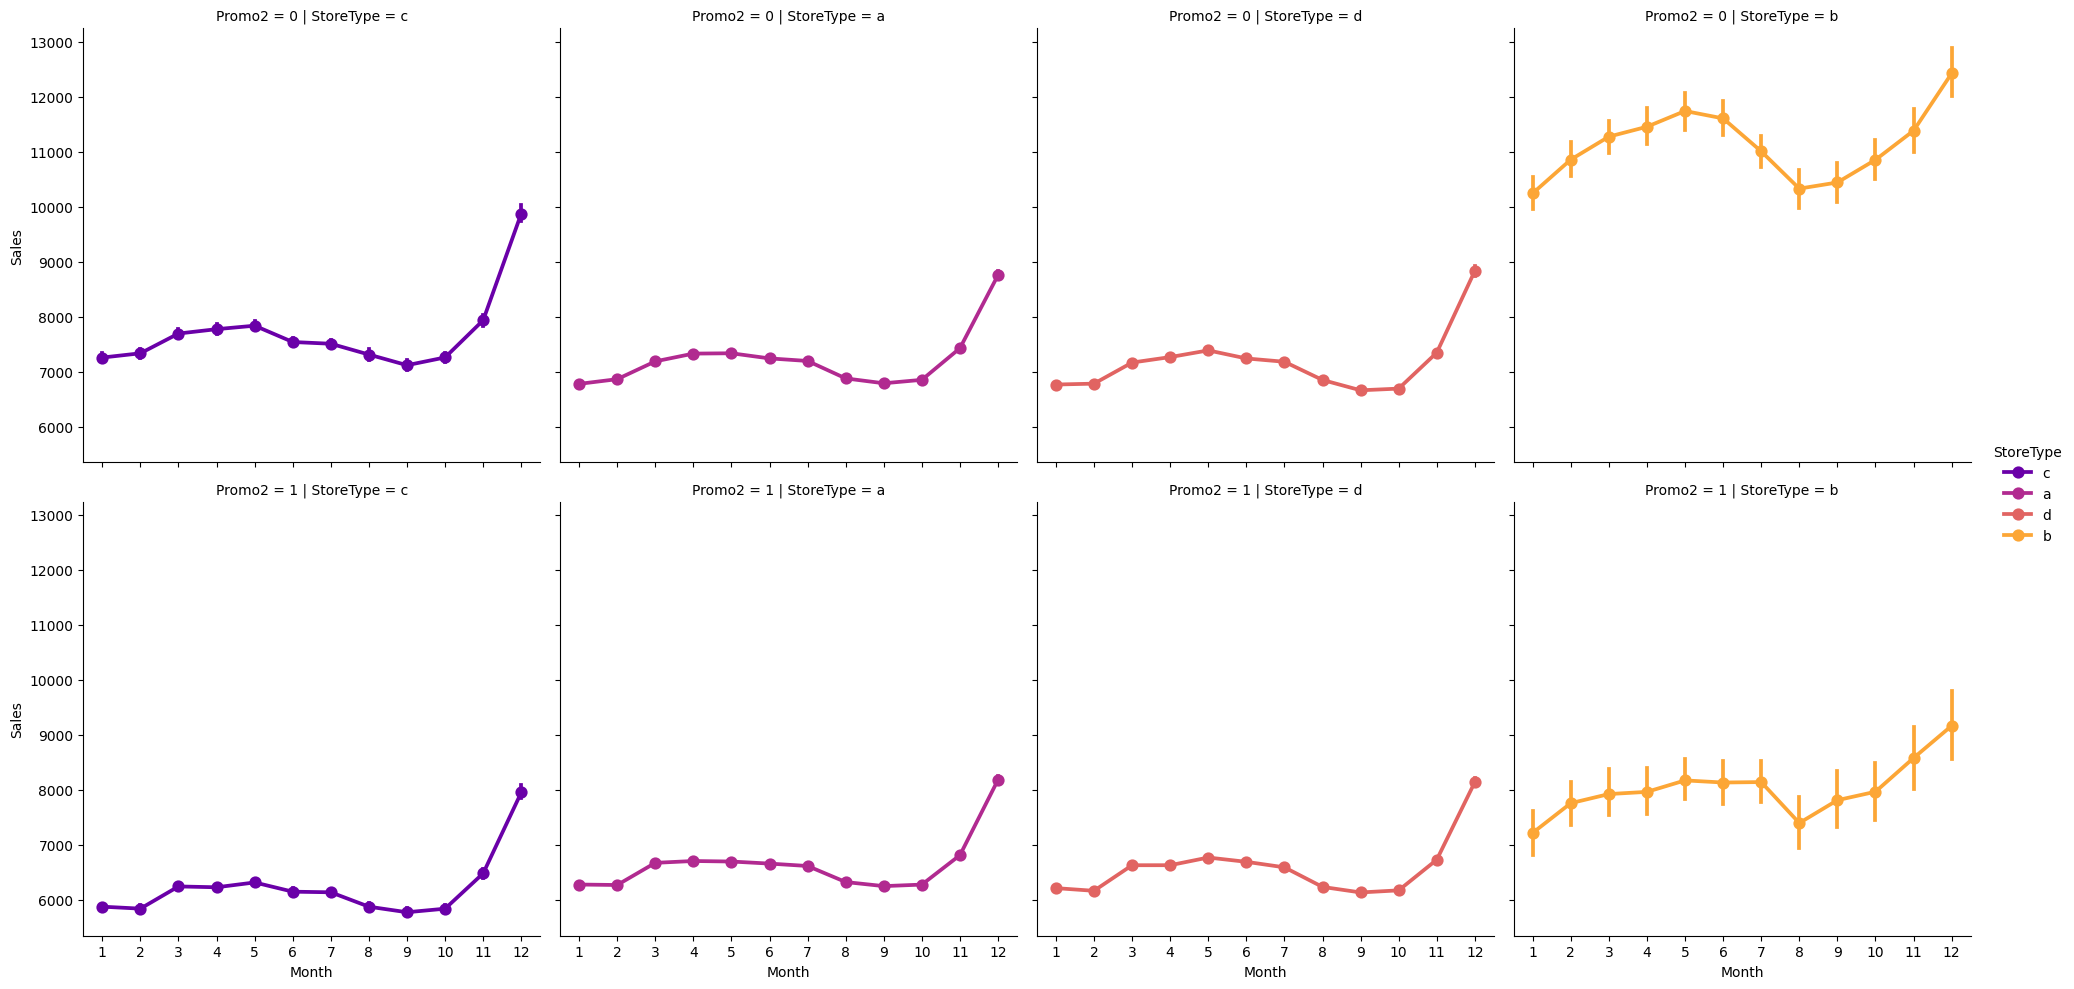

In [78]:
sns.catplot(data = train_store, 
            x = 'Month', 
            y = "Sales", 
            kind='point',
            col = 'StoreType', 
            palette = 'plasma',
            hue = 'StoreType',
            row = 'Promo2') 

In [79]:
train_store['PromoInterval'].unique()

array(['No Promo', 'Jan,Apr,Jul,Oct', 'Feb,May,Aug,Nov',
       'Mar,Jun,Sept,Dec'], dtype=object)

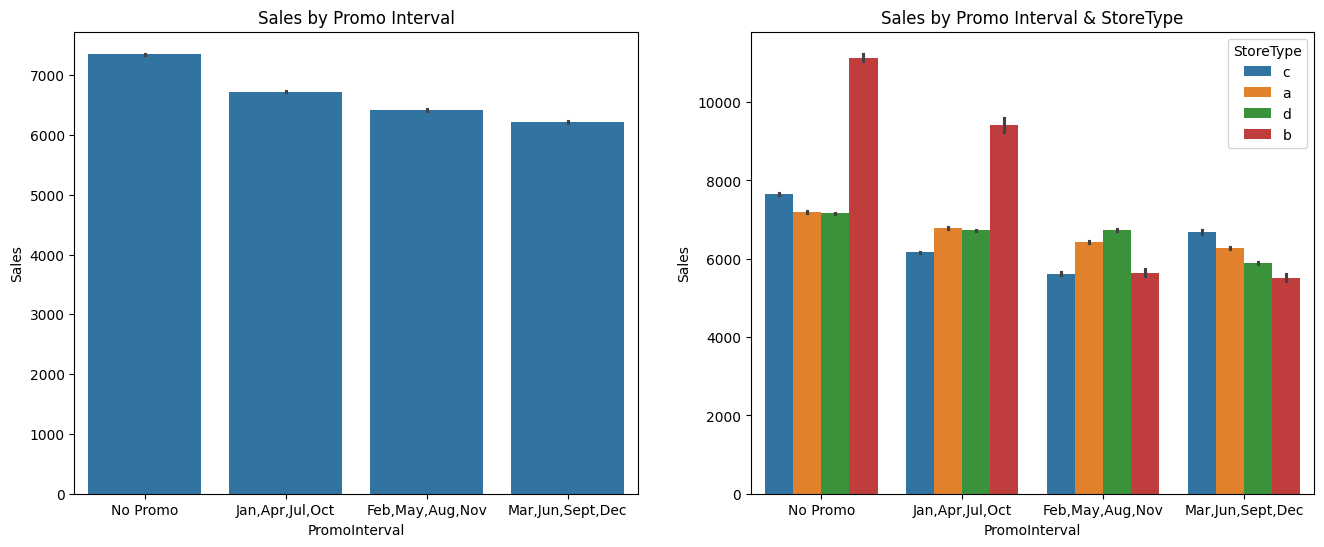

In [80]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=train_store, x='PromoInterval', y='Sales')
plt.title("Sales by Promo Interval")

plt.subplot(1, 2, 2)
sns.barplot(data=train_store, x='PromoInterval', y='Sales', hue='StoreType')
plt.title("Sales by Promo Interval & StoreType")

plt.show()

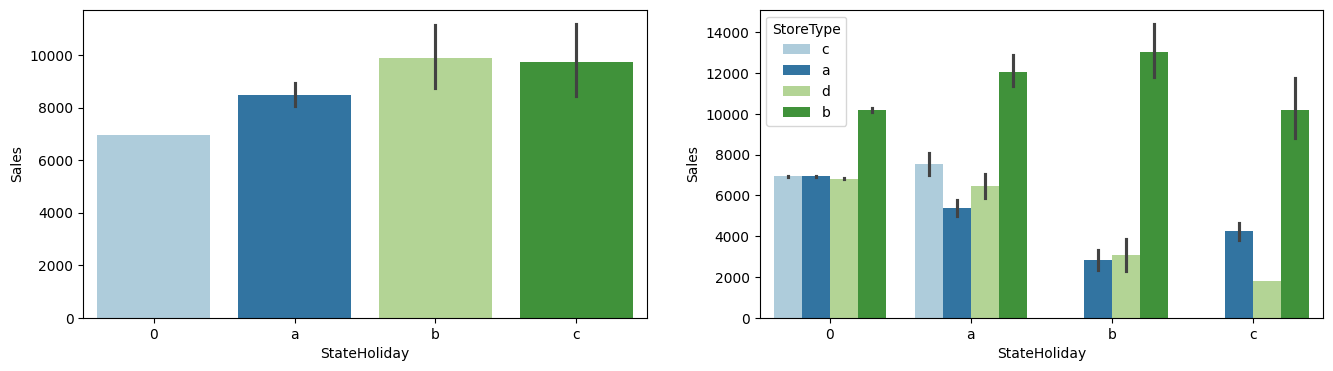

In [81]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
sns.barplot(data=train_store, x='StateHoliday', y='Sales', palette='Paired')

plt.subplot(1, 2, 2)
sns.barplot(data=train_store, x='StateHoliday', y='Sales', hue='StoreType', palette='Paired')

plt.show()

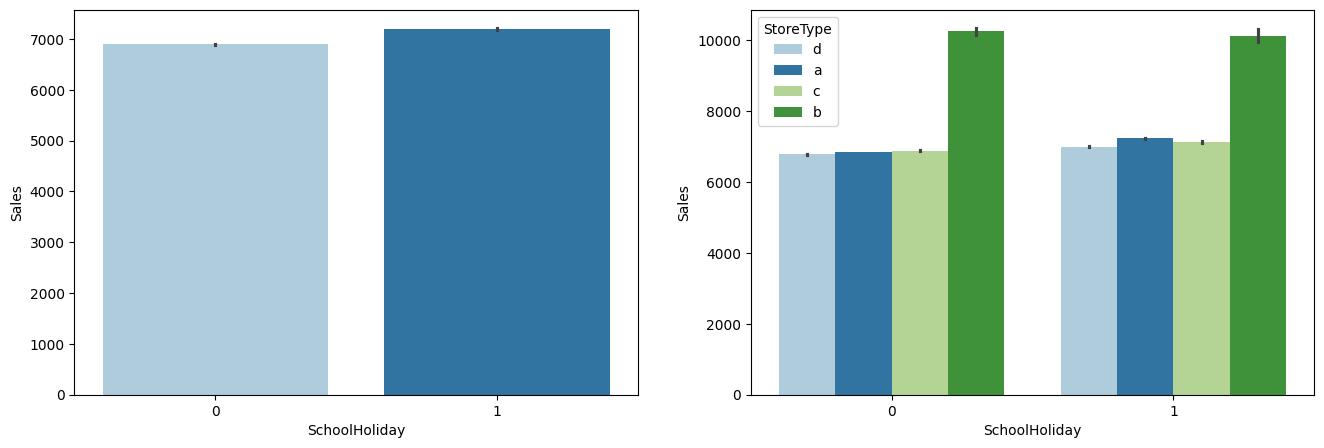

In [82]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=train_store, x='SchoolHoliday', y='Sales', palette='Paired')

plt.subplot(1, 2, 2)
sns.barplot(data=train_store, x='SchoolHoliday', y='Sales', hue='StoreType', palette='Paired')

plt.show()

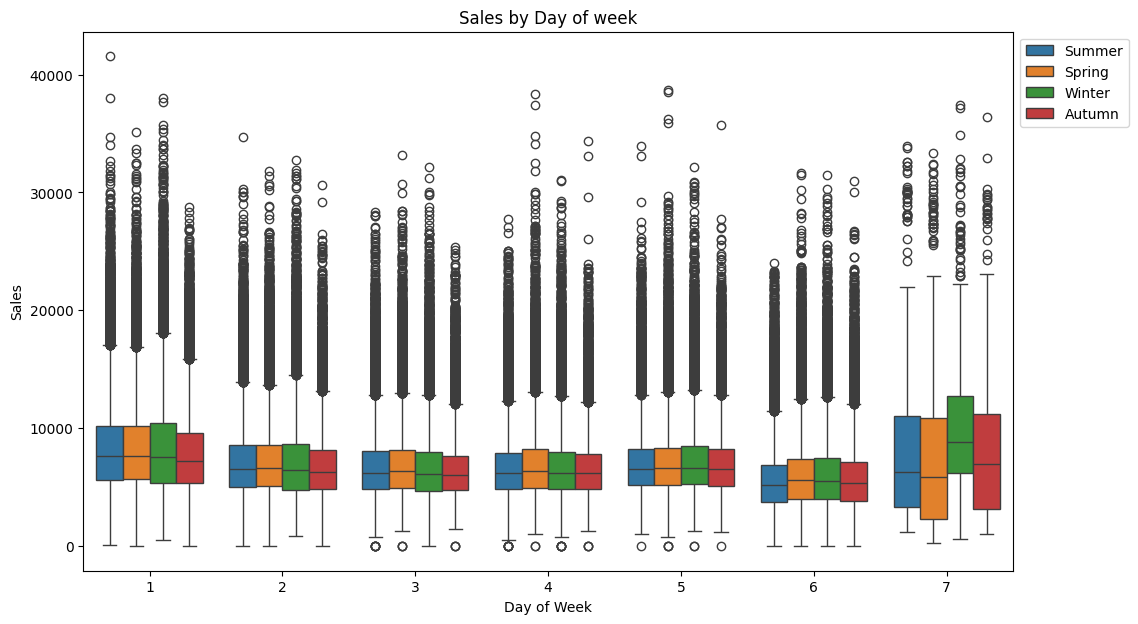

In [83]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(data=train_store, 
            x='DayOfWeek', 
            y='Sales', 
            hue='Seasons',
            ax=ax,
            linewidth=1)
ax.set_title('Sales by Day of week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Sales')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

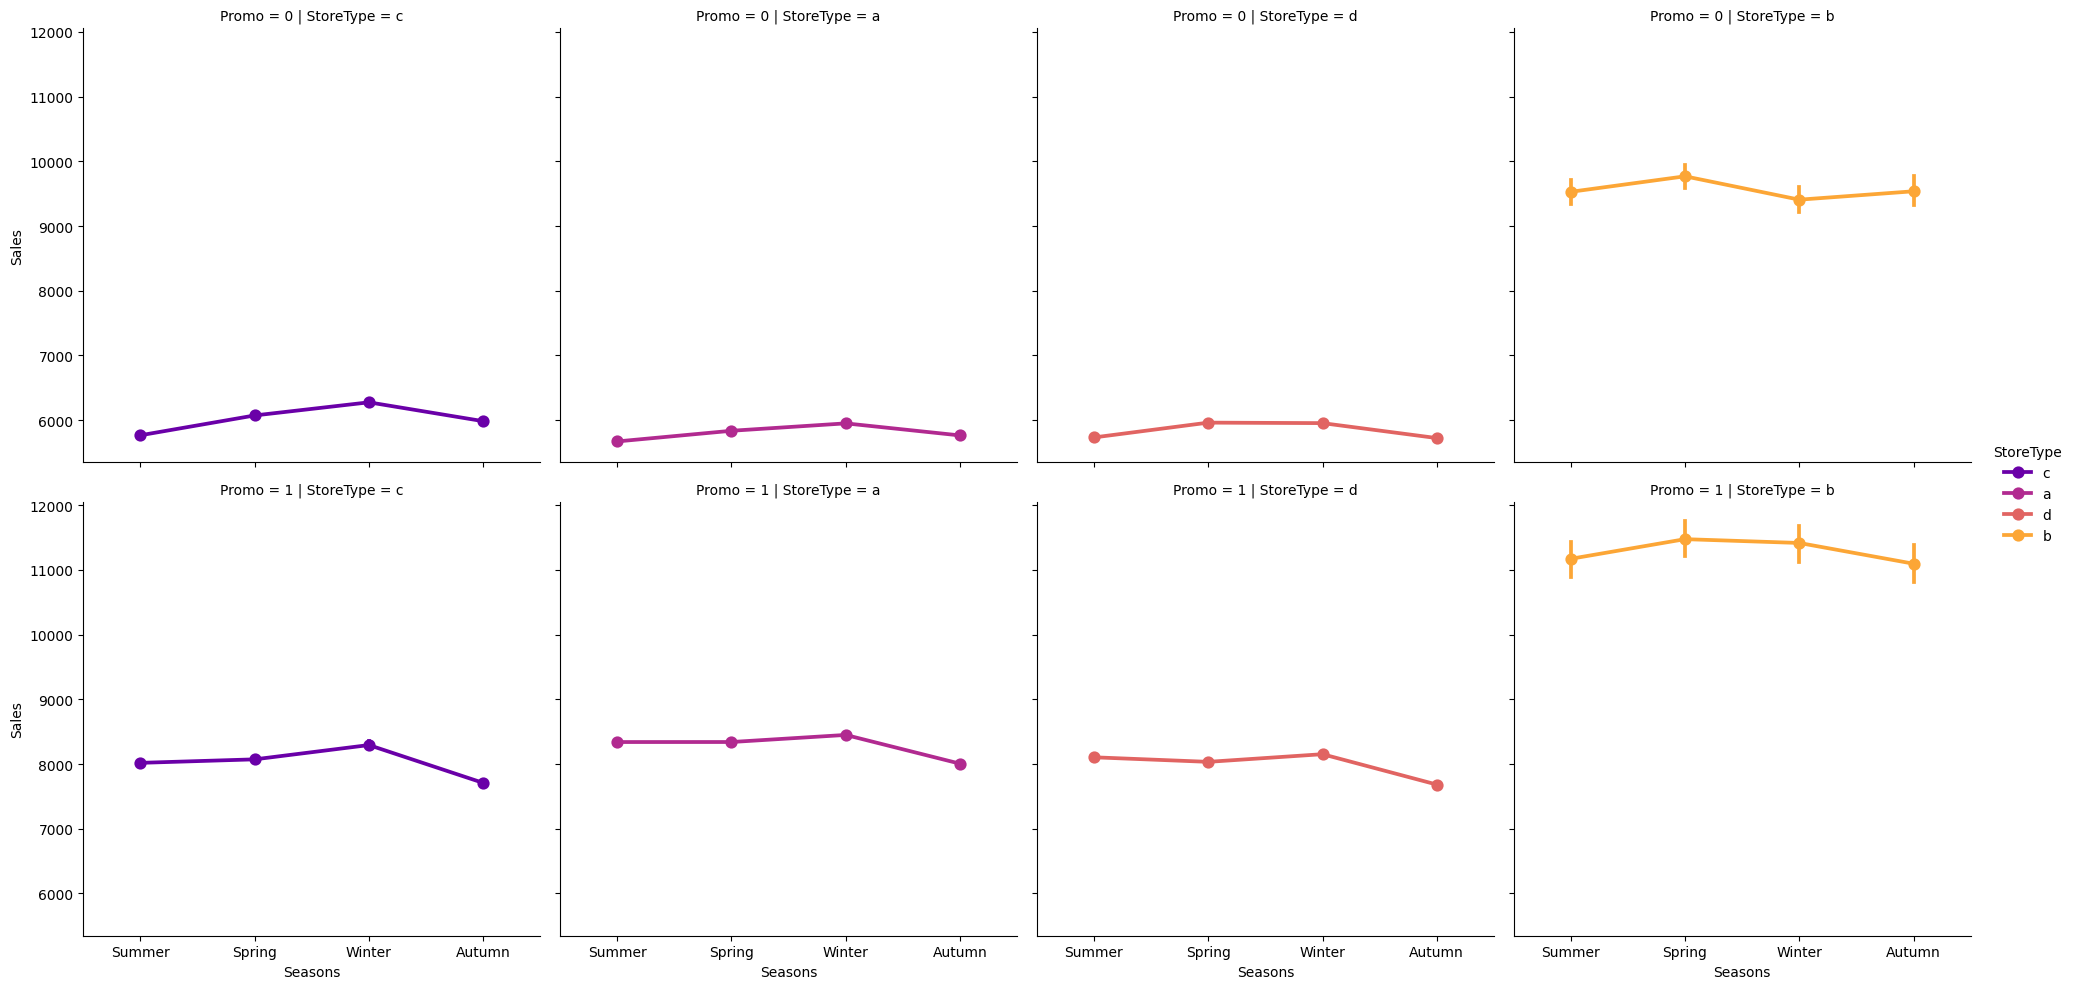

In [84]:
sns.catplot(data=train_store,
            x='Seasons',
            y='Sales',
            kind='point',
            col='StoreType',
            palette='plasma',
            hue='StoreType',
            row='Promo')

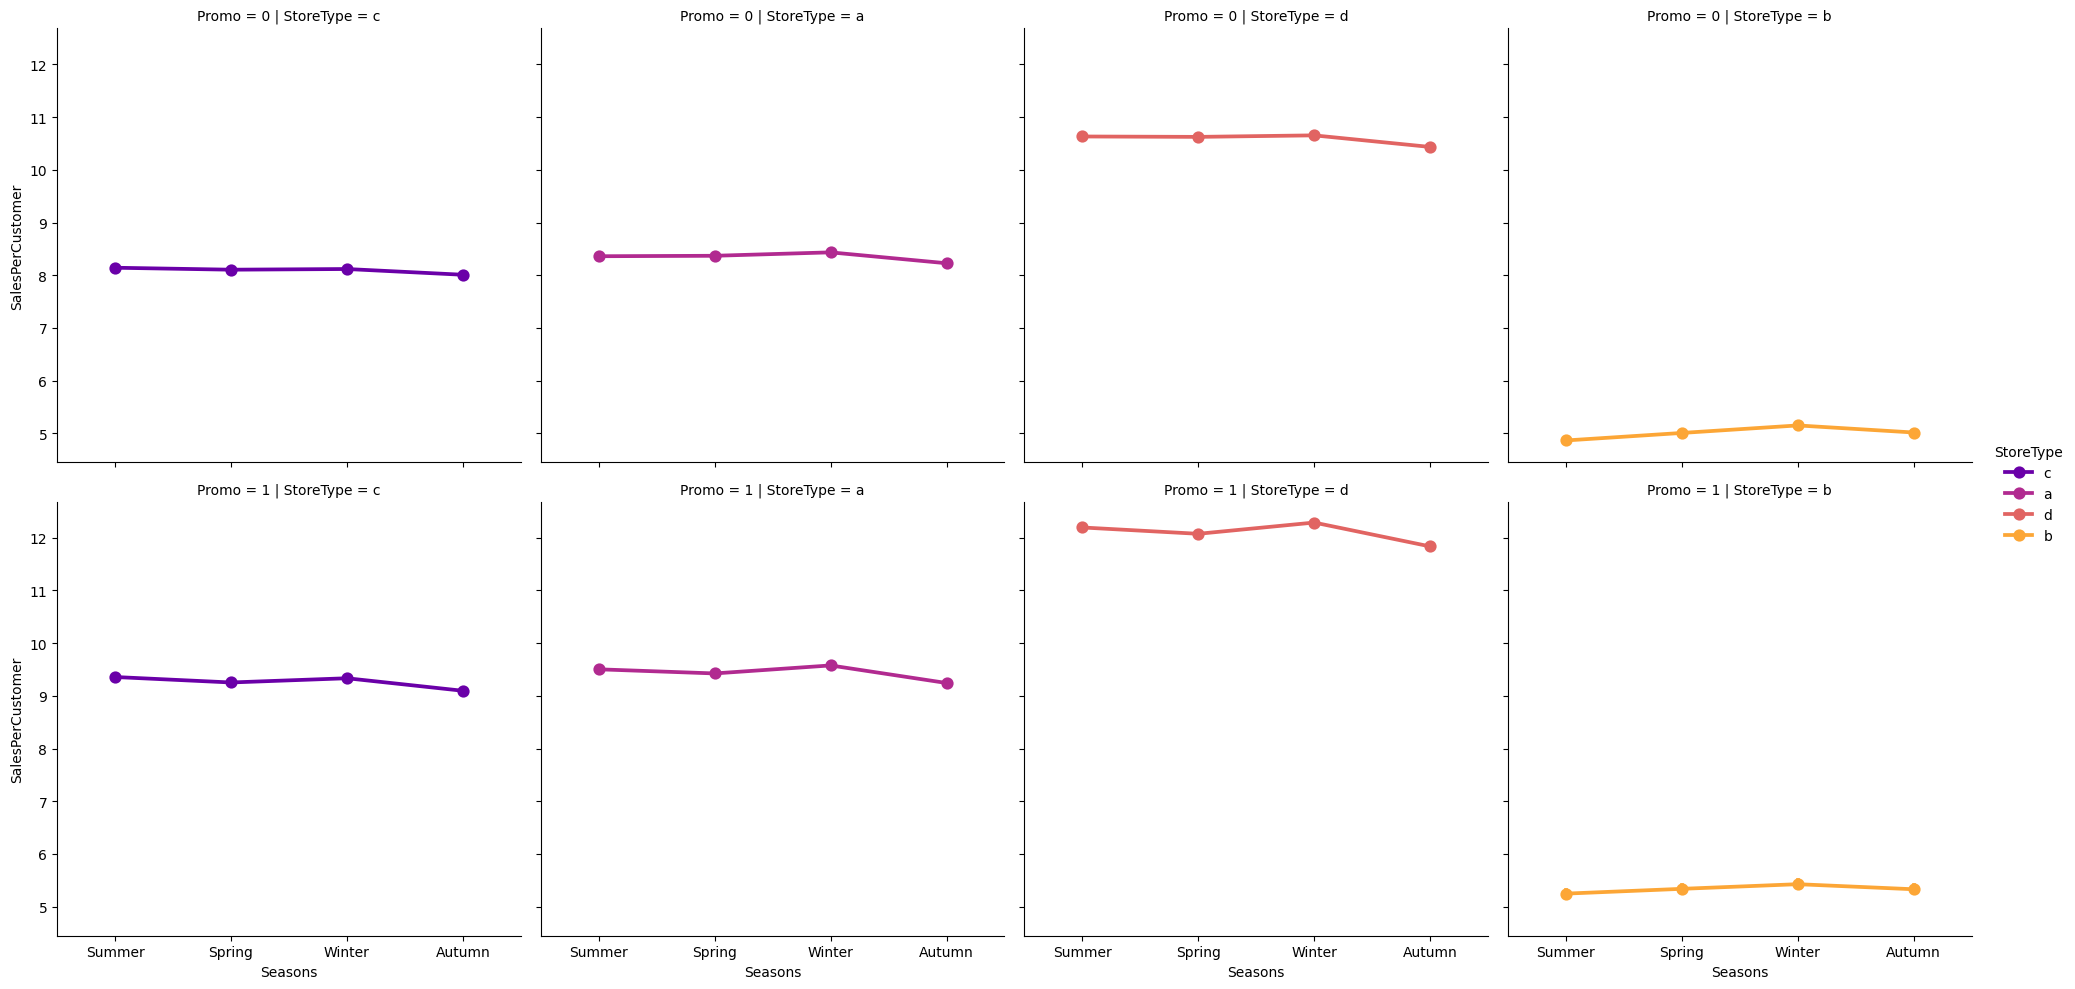

In [85]:
sns.catplot(data=train_store,
            x='Seasons',
            y='SalesPerCustomer',
            kind='point',
            col='StoreType',
            palette='plasma',
            hue='StoreType',
            row='Promo')

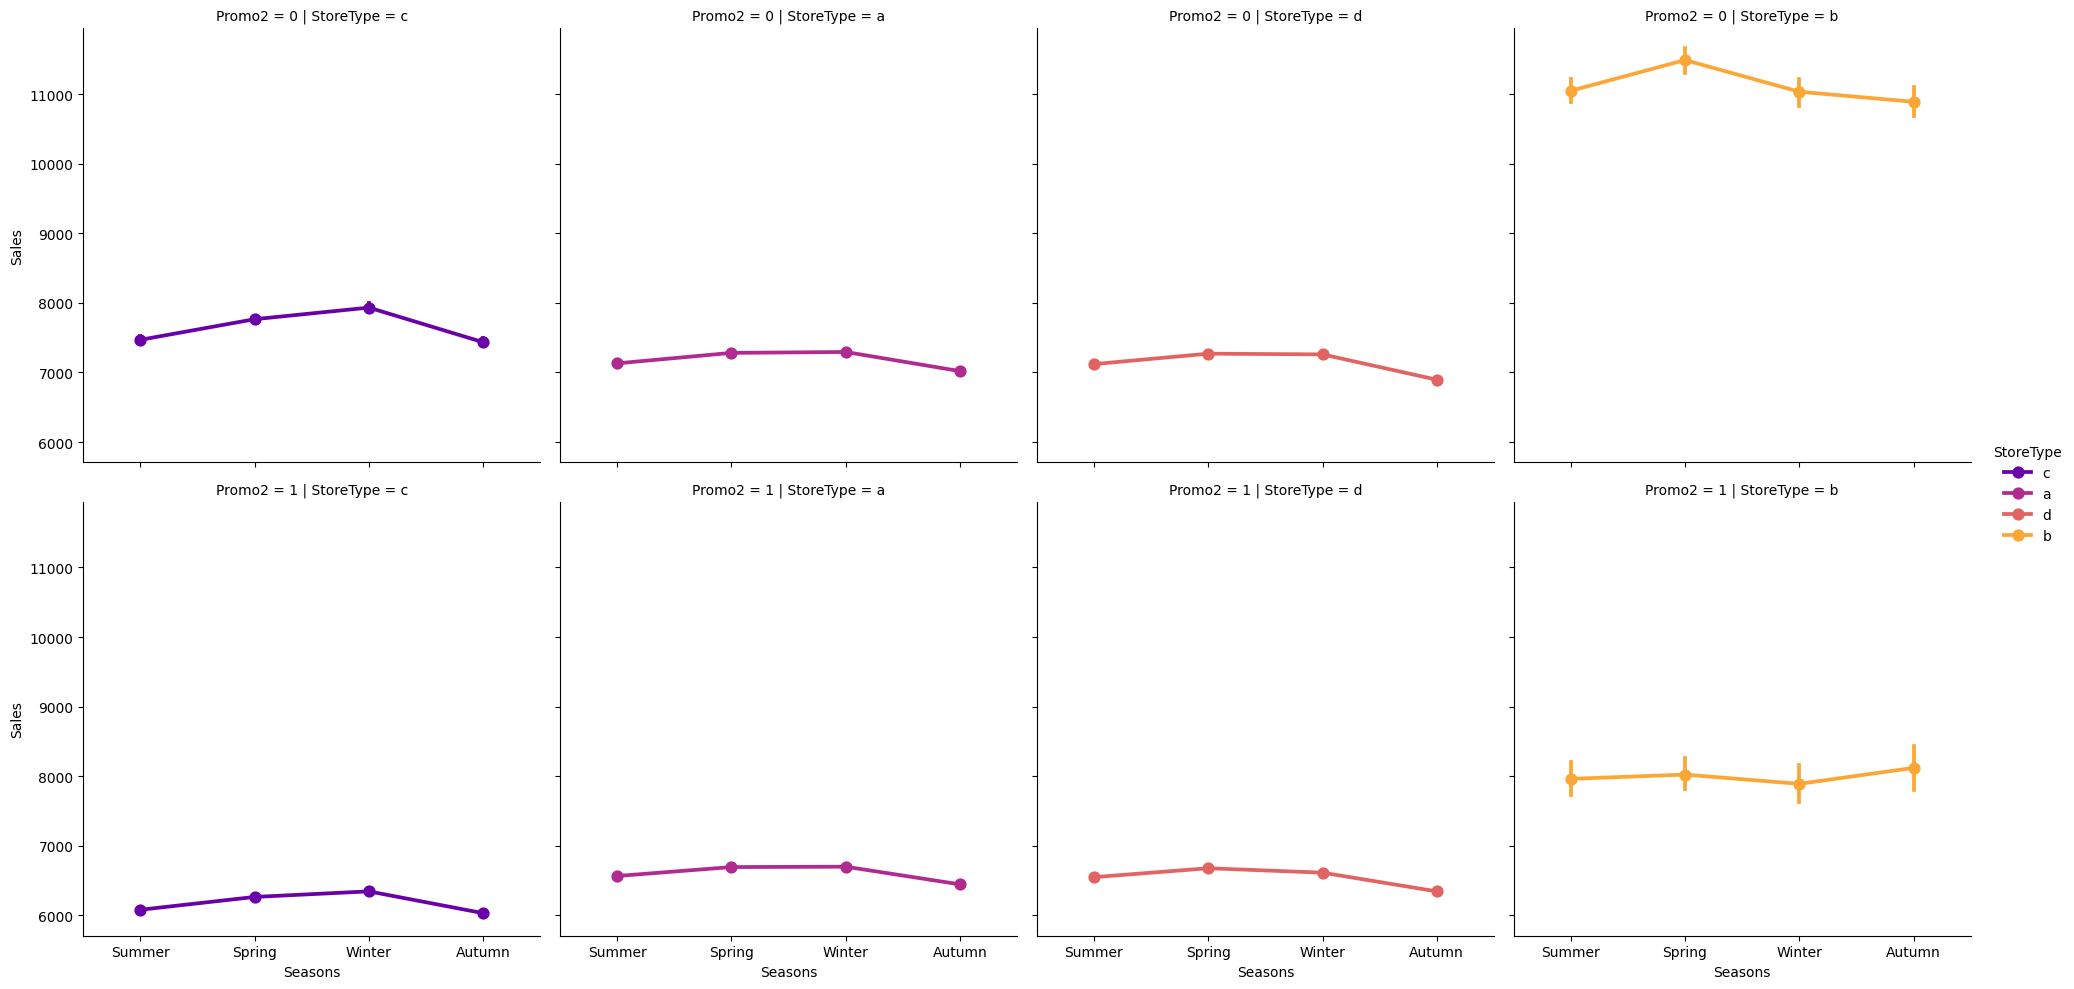

In [86]:
sns.catplot(data=train_store,
            x='Seasons',
            y='Sales',
            kind='point',
            col='StoreType',
            palette='plasma',
            hue='StoreType',
            row='Promo2')

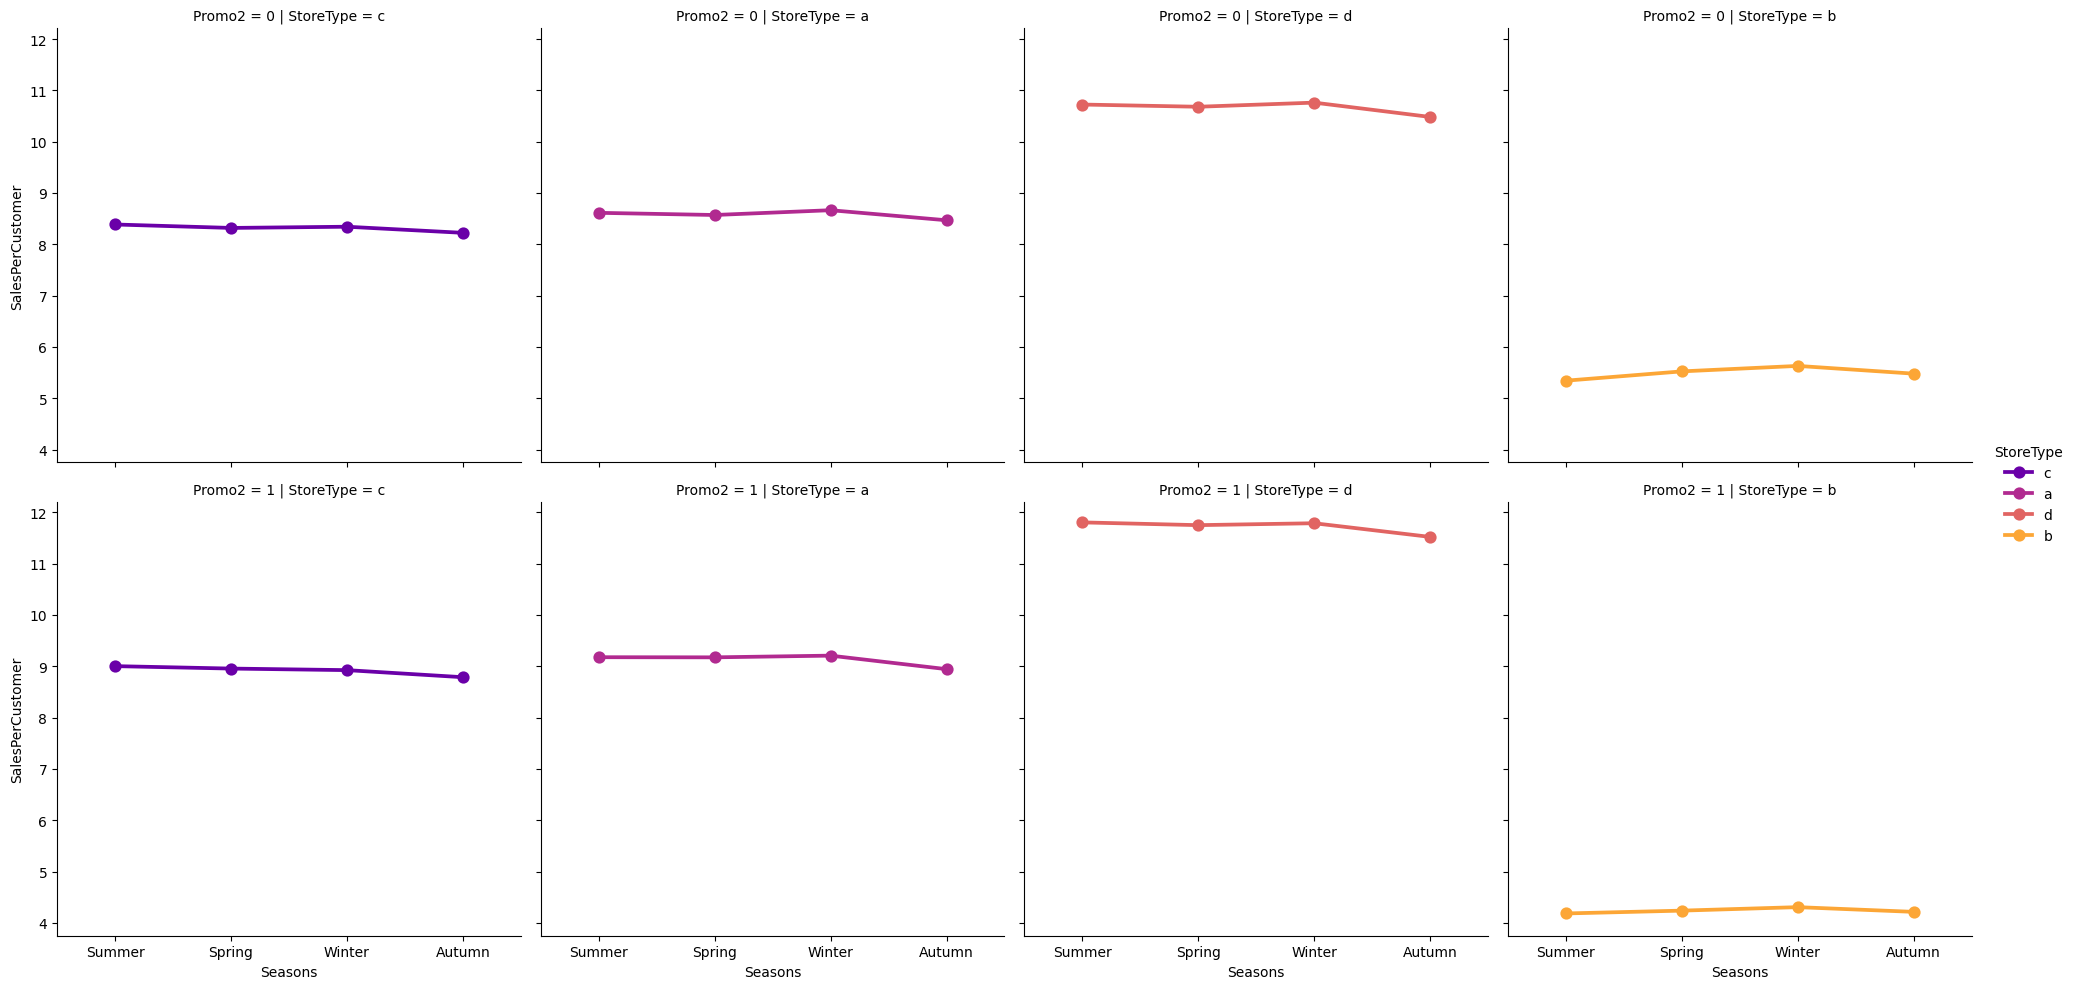

In [87]:
sns.catplot(data=train_store,
            x='Seasons',
            y='SalesPerCustomer',
            kind='point',
            col='StoreType',
            palette='plasma',
            hue='StoreType',
            row='Promo2')

In [88]:
train_store.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day',
       'WeekofYear', 'SalesPerCustomer', 'CompetitionOpen_month', 'Promo2Open',
       'Seasons'],
      dtype='object')

In [89]:
train_store.groupby('StoreType')[['Sales', 'Customers', 'Promo2Open', 'CompetitionOpen_month']].mean().sort_values(by='Sales', ascending=False).reset_index()

,StoreType,Sales,Customers,Promo2Open,CompetitionOpen_month
0,b,10231.407505,2021.822335,17199.117249,11366.961576
1,c,6932.512755,815.465887,12158.630388,6745.042106
2,a,6925.167661,795.361469,12917.7682,7115.659635
3,d,6822.141881,606.339876,10421.955706,9028.504575


In [90]:
num_cols = list(set(train_store.describe()) - set(['Date', 'Open', 'Store']))
num_cols

['Promo2Open',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'Month',
 'Customers',
 'Day',
 'CompetitionOpen_month',
 'CompetitionDistance',
 'Sales',
 'Promo',
 'Promo2',
 'WeekofYear',
 'SalesPerCustomer',
 'Year',
 'SchoolHoliday',
 'Promo2SinceWeek',
 'Promo2SinceYear',
 'DayOfWeek']

In [91]:
corr_mtrx = train_store[num_cols].corr()

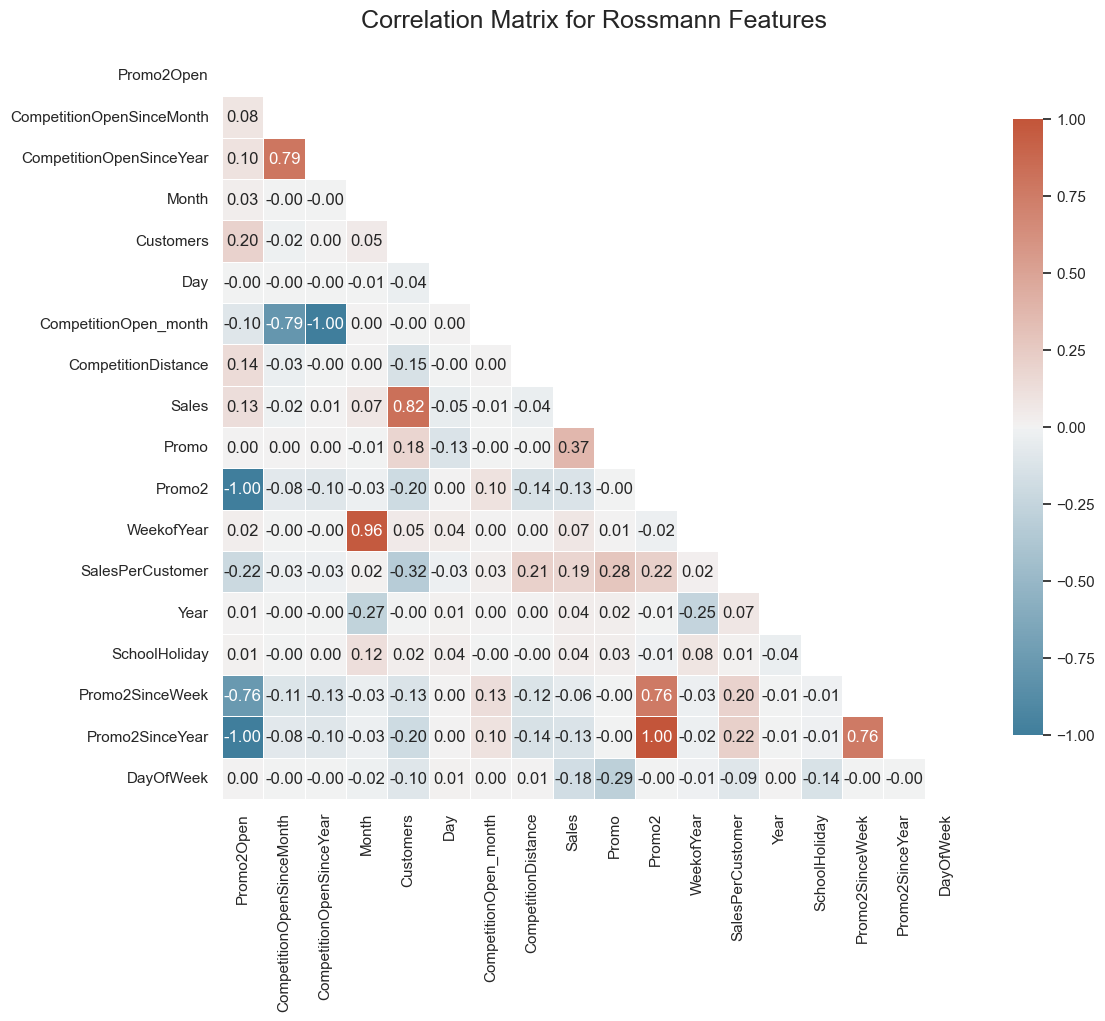

In [92]:
sns.set_theme(style="white")
plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_mtrx, dtype=bool))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_mtrx, 
    mask=mask,          
    cmap=cmap,          
    vmax=1,             
    vmin=-1,            
    center=0,           
    annot=True,         
    fmt='.2f',          
    linewidths=0.5,     
    cbar_kws={"shrink": .8}, 
    square=True         
)

plt.title("Correlation Matrix for Rossmann Features", fontsize=18, pad=20)
plt.show()

### Split Data

In [ ]:
# Sorting Data by Date
train_store = train_store.sort_values('Date')

# Specify Splits
tss = TimeSeriesSplit(n_splits=3)

# Specify Features (Input Values) and Target (Output values)
X = train_store.drop('Sales', axis=1)
y = train_store['Sales']

# Split data into X_train, X_test, y_train, y_test
for train_index, test_index in tss.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index] 

In [53]:
print(f"Train Period: {X_train['Date'].min()} to {X_train['Date'].max()}")
print(f"test Period: {X_test['Date'].min()} to {X_test['Date'].max()}")

Train Period: 2013-01-01 00:00:00 to 2014-12-10 00:00:00
test Period: 2014-12-10 00:00:00 to 2015-07-31 00:00:00


### Data Encoding

In [48]:
nominal_cat =  ['StoreType', 'StateHoliday']

In [ ]:
# Encoding categorical data to numerical 
assortment_order_map = {'a': 0, 'c': 1, 'b': 2}
X_train['Assortment'].replace(assortment_order_map, inplace=True)
X_test['Assortment'].replace(assortment_order_map, inplace=True)

# Encoding categorical data to numerical 
seasons_map = {'Winter':0, 'Spring':1, 'Summer': 2, 'Autumn':3}
X_train['Seasons'].replace(seasons_map, inplace=True)
X_test['Seasons'].replace(seasons_map, inplace=True)

# Encoding Train Data
one_h_enc_train_model = OneHotEncoder(sparse_output=False).fit(X_train[nominal_cat])
nominal_train_cat = one_h_enc_train_model.transform(X_train[nominal_cat])
new_cols_name_train = one_h_enc_train_model.get_feature_names_out(nominal_cat)
encoded_train_df = pd.DataFrame(nominal_train_cat, columns=new_cols_name_train, index=X_train.index)
X_train = pd.concat([X_train.drop(nominal_cat, axis=1), encoded_train_df], axis=1)

# Encoding test Data
nominal_test_cat = one_h_enc_train_model.transform(X_test[nominal_cat])
new_cols_name_test = one_h_enc_train_model.get_feature_names_out(nominal_cat)
encoded_test_df = pd.DataFrame(nominal_test_cat, columns=new_cols_name_test, index=X_test.index)
X_test = pd.concat([X_test.drop(nominal_cat, axis=1), encoded_test_df], axis=1)

# Drop PromoInterval, Date, Customers
X_train.drop(['PromoInterval', 'Date', 'Customers', 'SalesPerCustomer'], axis=1, inplace=True)
X_test.drop(['PromoInterval', 'Date', 'Customers', 'SalesPerCustomer'], axis=1,inplace=True)

In [ ]:
X_train

### Building Model

In [50]:
# Making the model
rf_model = RandomForestRegressor(n_estimators=100, min_samples_split=2, min_samples_leaf=1, max_features='sqrt').fit(X_train, y_train)

# Predicting Train data
y_pred_train = rf_model.predict(X_train)

# predicting Test data
y_pred = rf_model.predict(X_test)

# Check Performance on Train data
print(f"Train Data Performance:\n\
      RMSE: {root_mean_squared_error(y_train, y_pred_train)}\n\
      MAE: {mean_absolute_error(y_train, y_pred_train)}\n\
      Accuracy: {r2_score(y_train, y_pred_train)}") 

print('='*50)

# Check Performance on test data
print(f"Test Data Performance:\n\
      RMSE: {root_mean_squared_error(y_test, y_pred)}\n\
      MAE: {mean_absolute_error(y_test, y_pred)}\n\
      Accuracy: {r2_score(y_test, y_pred)}")

MemoryError: could not allocate 67108864 bytes

In [52]:
# Making the model
xgb_model = XGBRegressor(booster='gbtree', learning_rate=0.1, n_estimators=600, objective='reg:squarederror').fit(X_train, y_train)

# Predicting Train data
y_pred_train = xgb_model.predict(X_train)

# predicting Test data
y_pred = xgb_model.predict(X_test)

# Check Performance on Train data
print(f"Train Data Performance:\n\
      RMSE: {root_mean_squared_error(y_train, y_pred_train)}\n\
      MAE: {mean_absolute_error(y_train, y_pred_train)}\n\
      Accuracy: {r2_score(y_train, y_pred_train)}") 

print('='*50)

# Check Performance on test data
print(f"Test Data Performance:\n\
      RMSE: {root_mean_squared_error(y_test, y_pred)}\n\
      MAE: {mean_absolute_error(y_test, y_pred)}\n\
      Accuracy: {r2_score(y_test, y_pred)}")

Train Data Performance:
      RMSE: 828.1965942382812
      MAE: 589.6242065429688
      Accuracy: 0.9287204146385193
Test Data Performance:
      RMSE: 856.12841796875
      MAE: 600.8846435546875
      Accuracy: 0.9243550300598145


### Tuning Model

In [ ]:
# Define Parameters for RandomForest model
param_rf = {
    'n_estimators' : [50, 100, 150],
    'max_depth' : [5,10, 20, 30, None],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features' : ['sqrt', 'log2', None]
}

# set up randomforest randomized search
rf_search = RandomizedSearchCV(estimator=RandomForestRegressor(), param_distributions=param_rf, 
                               n_iter=10, cv=5, n_jobs=-1, verbose=3, random_state=43)

# fit the model
rf_search.fit(X_train, y_train)

# Best parameters
print(f"Best parameters: {rf_search.best_params_}")

# Best score
print(f"Best score: {rf_search.best_score_}")

In [ ]:
# Define Parameters for xgboost model
param_xg = {
    'booster' : ['gbtree', 'gblinear'],
    'n_estimators' : [80, 100, 300],
    'objective' : ['reg:squarederror', 'reg:squaredlogerror'],
    'learning_rate' : [0.1, 0.5, 0.01, 0.05]
}

# set up xgboost randomized search
xgb_search = RandomizedSearchCV(estimator=XGBRegressor(), param_distributions=param_xg, cv=5, n_jobs=-1, verbose=3)

# fit the model
xgb_search.fit(X_train, y_train)

# Best parameters
print(f"Best parameters: {xgb_search.best_params_}")

# Best score
print(f"Best score: {xgb_search.best_score_}")

In [ ]:
# Define Parameters for xgboost model
param_xg = {
    'booster' : ['gbtree', 'gblinear'],
    'n_estimators' : [80, 100, 300, 500, 600],
    'objective' : ['reg:squarederror', 'reg:squaredlogerror'],
    'learning_rate' : [0.1, 0.5, 0.01, 0.05, 0.001]
}

# set up xgboost Grid search
xgb_search = GridSearchCV(estimator=XGBRegressor(), param_grid=param_xg, cv=5, n_jobs=-1, verbose=3)

# fit the model
xgb_search.fit(X_train, y_train)

# Best parameters
print(f"Best parameters: {xgb_search.best_params_}")

# Best score
print(f"Best score: {xgb_search.best_score_}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits


In [3]:
import mlflow
print(mlflow.__version__)

C:\Users\marve\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


3.12.0
